# UMAP analysis for top-performing worm classification model families

This notebook selects the best run from each model family and visualises the learned image embeddings with UMAP.

It is intended for the multi-task earthworm classification project, where the trained models predict:

- `genus`
- `species`
- `age`

The notebook:

1. scans all `node_local_sweep_*` directories;
2. aggregates `multi_run_results.csv` files;
3. infers the model family from `run_overrides.args` or `config.json`;
4. selects the best run per model family using `best_val_score`;
5. loads each selected checkpoint;
6. extracts backbone embeddings;
7. computes 2D UMAP projections;
8. plots the same embedding coloured by each task label and by prediction correctness.

For scientific reporting, use these plots as **diagnostic visualisations**, not as primary evidence of classification accuracy. Quantitative claims should still come from held-out test-set metrics, preferably at the individual-worm level.


In [1]:
from __future__ import annotations

import copy
import json
import re
import shlex
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from IPython.display import display, Markdown

try:
    import umap
except ImportError as exc:
    raise ImportError(
        "The package `umap-learn` is required. Install it in your environment with:\n"
        "    pip install umap-learn\n"
        "or, with conda:\n"
        "    conda install -c conda-forge umap-learn"
    ) from exc

from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

from src.dataset_multitask import (
    build_transforms,
    get_target_cols,
    prepare_metadata,
)

from src.models import build_model

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 180)


## 1. User settings

Edit these paths if your project or dataset is mounted elsewhere.

In [2]:
PROJECT_ROOT = Path("~/worm-species").expanduser().resolve()
OUTPUTS_ROOT = PROJECT_ROOT / "outputs_slurm"

# Override these if config.json refers to node-local scratch.
DATA_ROOT_OVERRIDE = Path("/mnt/extssd/Earthworms/petridish-worm-images")
METADATA_CSV_OVERRIDE = Path("/mnt/extssd/Earthworms/petridish-worm-images/01_Segmented/global_metadata.csv")

# Model-selection metric. Prefer validation metrics for choosing models.
RANK_BY = "best_val_score"

TASKS_TO_PLOT = ["species", "genus", "age"]

# Embedding extraction settings.
BATCH_SIZE = 64
NUM_WORKERS = 0

# UMAP settings.
MAX_IMAGES_PER_MODEL = 2500
MAX_IMAGES_PER_CLASS = 250
RANDOM_STATE = 42
UMAP_N_NEIGHBORS = 25
UMAP_MIN_DIST = 0.10
UMAP_METRIC = "cosine"

# If a split column exists, prefer test rows for visualisation.
PREFERRED_SPLITS = ["test", "val", "validation"]

ANALYSIS_DIR = OUTPUTS_ROOT / "combined_sweep_analysis" / "umap_top_model_families"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Project root:", PROJECT_ROOT)
print("Outputs root:", OUTPUTS_ROOT)
print("Analysis directory:", ANALYSIS_DIR)
print("Device:", DEVICE)


Project root: /home/devd/worm-species
Outputs root: /home/devd/worm-species/outputs_slurm
Analysis directory: /home/devd/worm-species/outputs_slurm/combined_sweep_analysis/umap_top_model_families
Device: cuda


## 2. Discover sweeps and aggregate results

In [3]:
def find_sweep_dirs(outputs_root: Path) -> list[Path]:
    sweep_dirs = sorted(outputs_root.glob("node_local_sweep_*"))
    sweep_dirs = [
        p.resolve()
        for p in sweep_dirs
        if p.exists() and any(p.glob("run_*/multi_run_results.csv"))
    ]

    if not sweep_dirs:
        raise FileNotFoundError(
            f"No sweep directories containing run_*/multi_run_results.csv found under {outputs_root}"
        )

    return sweep_dirs


SWEEP_DIRS = find_sweep_dirs(OUTPUTS_ROOT)

print("Found sweep directories:")
for sweep_dir in SWEEP_DIRS:
    n = len(list(sweep_dir.glob("run_*/multi_run_results.csv")))
    print(f"  {sweep_dir.name}: {n} result files")


Found sweep directories:
  node_local_sweep_20260703_164317: 83 result files
  node_local_sweep_20260706_122839: 248 result files


In [4]:
def read_one_results_csv(csv_path: Path, sweep_dir: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    df["source_csv"] = str(csv_path)
    df["source_run_dir"] = str(csv_path.parent)
    df["source_run_id"] = csv_path.parent.name
    df["sweep_dir"] = str(sweep_dir)
    df["sweep_id"] = sweep_dir.name
    return df


frames = []
bad_csvs = []

for sweep_dir in SWEEP_DIRS:
    for csv_path in sorted(sweep_dir.glob("run_*/multi_run_results.csv")):
        try:
            df_i = read_one_results_csv(csv_path, sweep_dir)
            if len(df_i) > 0:
                frames.append(df_i)
        except Exception as exc:
            bad_csvs.append((str(csv_path), repr(exc)))

if not frames:
    raise RuntimeError("No non-empty multi_run_results.csv files were found.")

results = pd.concat(frames, ignore_index=True)

non_numeric = {
    "run_name",
    "out_dir",
    "selection_metric",
    "source_csv",
    "source_run_dir",
    "source_run_id",
    "sweep_dir",
    "sweep_id",
}

for col in results.columns:
    if col not in non_numeric:
        results[col] = pd.to_numeric(results[col], errors="ignore")

print("Aggregated runs:", len(results))
print("Sweeps included:", results["sweep_id"].nunique())

display(results.groupby("sweep_id").size().reset_index(name="n_runs"))

if bad_csvs:
    display(pd.DataFrame(bad_csvs, columns=["csv_path", "error"]))


Aggregated runs: 331
Sweeps included: 2


/tmp/ipykernel_551838/2925940942.py:41: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  results[col] = pd.to_numeric(results[col], errors="ignore")


,sweep_id,n_runs
0,node_local_sweep_20260703_164317,83
1,node_local_sweep_20260706_122839,248


## 3. Resolve run artefact directories

This handles the common situation where `out_dir` in the CSV points to `/scratch/...`, but persistent artefacts are copied into the sweep directory.


In [5]:
EXPECTED_FILES = (
    ["test_metrics.json", "config.json", "label_to_index_by_task.json", "best_model.pt", "history.csv"]
    + [f"classification_report_{task}.csv" for task in TASKS_TO_PLOT]
    + [f"confusion_matrix_{task}.csv" for task in TASKS_TO_PLOT]
)


def has_any_artifact(path: Path) -> bool:
    return path.exists() and path.is_dir() and any((path / name).exists() for name in EXPECTED_FILES)


def candidate_artifact_dirs(row: pd.Series) -> list[Path]:
    source_run_dir = Path(str(row["source_run_dir"]))
    run_name = str(row.get("run_name", "")).strip()
    out_dir = str(row.get("out_dir", "")).strip()

    candidates = []

    if out_dir and out_dir.lower() != "nan":
        candidates.append(Path(out_dir).expanduser())

    if run_name and run_name.lower() != "nan":
        candidates.append(source_run_dir / run_name)

    if source_run_dir.exists():
        for child in sorted(source_run_dir.iterdir()):
            if child.is_dir():
                candidates.append(child)

    seen = set()
    unique = []
    for c in candidates:
        key = str(c)
        if key not in seen:
            seen.add(key)
            unique.append(c)

    return unique


def resolve_artifact_dir(row: pd.Series) -> str | None:
    for candidate in candidate_artifact_dirs(row):
        if has_any_artifact(candidate):
            return str(candidate.resolve())

    for candidate in candidate_artifact_dirs(row):
        if candidate.exists() and candidate.is_dir():
            return str(candidate.resolve())

    return None


results["artifact_dir"] = results.apply(resolve_artifact_dir, axis=1)
results["has_artifacts"] = results["artifact_dir"].map(lambda p: bool(p) and has_any_artifact(Path(p)))

print("Rows with expected artefacts:", results["has_artifacts"].sum(), "/", len(results))


Rows with expected artefacts: 331 / 331


## 4. Infer model family and select the best run per family

In [6]:
def safe_slug(text: str, max_len: int = 90) -> str:
    text = str(text)
    text = re.sub(r"[^a-zA-Z0-9_.-]+", "_", text)
    text = text.strip("_")
    if len(text) > max_len:
        text = text[:max_len].rstrip("_")
    return text or "unnamed"


def read_run_overrides(row: pd.Series) -> tuple[str, Path | None]:
    candidates = []

    if "source_run_dir" in row and pd.notna(row["source_run_dir"]):
        candidates.append(Path(row["source_run_dir"]) / "run_overrides.args")

    if "artifact_dir" in row and pd.notna(row["artifact_dir"]):
        candidates.append(Path(row["artifact_dir"]).parent / "run_overrides.args")

    for path in candidates:
        if path.exists():
            return path.read_text().strip(), path

    return "", None


def parse_overrides_to_dict(override_text: str) -> dict[str, str]:
    if not override_text:
        return {}

    try:
        tokens = shlex.split(" ".join(override_text.split()))
    except ValueError:
        tokens = override_text.split()

    out = {}
    i = 0

    while i < len(tokens):
        tok = tokens[i]

        if tok.startswith("--") and "=" in tok:
            key, value = tok.lstrip("-").split("=", 1)
            out[key] = value
            i += 1

        elif tok.startswith("--") and i + 1 < len(tokens):
            key = tok.lstrip("-")
            value = tokens[i + 1]
            out[key] = value
            i += 2

        elif "=" in tok:
            key, value = tok.split("=", 1)
            out[key] = value
            i += 1

        else:
            i += 1

    return out


def compact_overrides_text(override_text: str, max_chars: int = 260) -> str:
    if not override_text:
        return "Parameters: run_overrides.args not found"

    parsed = parse_overrides_to_dict(override_text)

    if parsed:
        preferred_keys = [
            "model.name",
            "training.lr",
            "training.batch_size",
            "model.freeze_backbone",
            "multitask.loss_weights.age",
            "data.image_col",
            "data.image_size",
            "data.crop_to_foreground",
            "data.crop_pad",
        ]
        parts = [f"{k}={parsed[k]}" for k in preferred_keys if k in parsed]

        if not parts:
            parts = [f"{k}={v}" for k, v in parsed.items()]
    else:
        parts = [" ".join(override_text.split())]

    summary = " | ".join(parts)

    if len(summary) > max_chars:
        summary = summary[:max_chars].rstrip() + " ..."

    return f"Parameters: {summary}"


def model_type_from_config(row: pd.Series) -> str | None:
    if "artifact_dir" not in row or pd.isna(row["artifact_dir"]):
        return None

    config_path = Path(row["artifact_dir"]) / "config.json"

    if not config_path.exists():
        return None

    try:
        with open(config_path, "r") as f:
            cfg = json.load(f)
        return cfg.get("model", {}).get("name")
    except Exception:
        return None


def infer_model_type(row: pd.Series) -> str:
    override_text, _ = read_run_overrides(row)
    parsed = parse_overrides_to_dict(override_text)

    if "model.name" in parsed:
        return str(parsed["model.name"])

    from_config = model_type_from_config(row)
    if from_config is not None:
        return str(from_config)

    run_name = str(row.get("run_name", ""))
    if "__" in run_name:
        return run_name.split("__")[0]

    return "unknown_model"


results["model_type"] = results.apply(infer_model_type, axis=1)

if RANK_BY not in results.columns:
    fallback = ["best_val_score", "test_mean_macro_f1", "test_species_macro_f1"]
    RANK_BY = next((c for c in fallback if c in results.columns), None)
    if RANK_BY is None:
        raise KeyError("No suitable ranking metric found.")

ranked = (
    results
    .copy()
    .sort_values(RANK_BY, ascending=False, na_position="last")
    .reset_index(drop=True)
)
ranked["rank"] = np.arange(1, len(ranked) + 1)

display(
    ranked
    .groupby("model_type")
    .size()
    .reset_index(name="n_runs")
    .sort_values("n_runs", ascending=False)
)


,model_type,n_runs
3,resnet18,67
2,efficientnet_b1,66
4,resnet50,66
5,vit_b_16,63
0,convnext_base,52
1,efficientnet_b0,17


In [7]:
top_by_model = (
    ranked[ranked["has_artifacts"]]
    .sort_values(RANK_BY, ascending=False, na_position="last")
    .groupby("model_type", as_index=False)
    .head(1)
    .sort_values(RANK_BY, ascending=False)
    .reset_index(drop=True)
)

top_by_model["model_family_rank"] = np.arange(1, len(top_by_model) + 1)

summary_cols = [
    "model_family_rank",
    "model_type",
    "sweep_id",
    "source_run_id",
    "run_name",
    RANK_BY,
    "test_mean_macro_f1",
    "test_species_macro_f1",
    "test_species_balanced_accuracy",
    "test_species_accuracy",
    "test_genus_macro_f1",
    "test_age_macro_f1",
    "test_complete_exact_match_accuracy",
    "artifact_dir",
]
summary_cols = [c for c in summary_cols if c in top_by_model.columns]

display(top_by_model[summary_cols])

top_csv = ANALYSIS_DIR / f"top_run_per_model_family_by_{RANK_BY}.csv"
top_by_model[summary_cols].to_csv(top_csv, index=False)
print("Saved:", top_csv)


,model_family_rank,model_type,sweep_id,source_run_id,run_name,best_val_score,test_mean_macro_f1,test_species_macro_f1,test_species_balanced_accuracy,test_species_accuracy,test_genus_macro_f1,test_age_macro_f1,test_complete_exact_match_accuracy,artifact_dir
0,1,convnext_base,node_local_sweep_20260706_122839,run_028,convnext_base__rel_path_seg__genus__0260c63d,0.868806,0.900932,0.908144,0.901558,0.931889,0.975764,0.818890,0.769350,/home/devd/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_028/convnext_base__rel_path_seg__genus__0260c63d
1,2,resnet18,node_local_sweep_20260706_122839,run_179,resnet18__rel_path_seg__genus__68d3b62a,0.843412,0.885542,0.867201,0.883449,0.902477,0.967534,0.821892,0.701238,/home/devd/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_179/resnet18__rel_path_seg__genus__68d3b62a
2,3,vit_b_16,node_local_sweep_20260706_122839,run_146,vit_b_16__rel_path_seg__genus__d413182b,0.840440,0.898461,0.894019,0.890075,0.919505,0.976783,0.824580,0.738390,/home/devd/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_146/vit_b_16__rel_path_seg__genus__d413182b
3,4,efficientnet_b1,node_local_sweep_20260706_122839,run_308,efficientnet_b1__rel_path_seg__genus__ba032066,0.828307,0.881059,0.863313,0.879597,0.883901,0.961694,0.818171,0.721362,/home/devd/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_308/efficientnet_b1__rel_path_seg__genus__ba032066
4,5,efficientnet_b0,node_local_sweep_20260703_164317,run_030,efficientnet_b0__rel_path_seg__genus__9a61bcaf,0.822379,0.876219,0.869487,0.888532,0.902477,0.951159,0.808012,0.739938,/home/devd/worm-species/outputs_slurm/node_local_sweep_20260703_164317/run_030/efficientnet_b0__rel_path_seg__genus__9a61bcaf
5,6,resnet50,node_local_sweep_20260706_122839,run_241,resnet50__rel_path_seg__genus__531efe2f,0.817868,0.866565,0.814368,0.805012,0.856037,0.961479,0.823850,0.699690,/home/devd/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_241/resnet50__rel_path_seg__genus__531efe2f


Saved: /home/devd/worm-species/outputs_slurm/combined_sweep_analysis/umap_top_model_families/top_run_per_model_family_by_best_val_score.csv


## 5. Multi-task model reconstruction and embedding extraction

In [8]:
class MultiTaskClassifier(nn.Module):
    """
    Shared image backbone with one classification head per task.
    """

    def __init__(self, base_model: nn.Module, num_classes_by_task: dict[str, int]):
        super().__init__()
        self.backbone = base_model
        feature_dim = self._remove_classifier_and_get_feature_dim()

        self.heads = nn.ModuleDict({
            task: nn.Linear(feature_dim, num_classes)
            for task, num_classes in num_classes_by_task.items()
        })

    def _remove_classifier_and_get_feature_dim(self) -> int:
        # ResNet-style models
        if hasattr(self.backbone, "fc") and isinstance(self.backbone.fc, nn.Linear):
            feature_dim = self.backbone.fc.in_features
            self.backbone.fc = nn.Identity()
            return feature_dim

        # EfficientNet, ConvNeXt, MobileNet, DenseNet-style models
        if hasattr(self.backbone, "classifier"):
            classifier = self.backbone.classifier

            if isinstance(classifier, nn.Linear):
                feature_dim = classifier.in_features
                self.backbone.classifier = nn.Identity()
                return feature_dim

            if isinstance(classifier, nn.Sequential):
                for i in range(len(classifier) - 1, -1, -1):
                    if isinstance(classifier[i], nn.Linear):
                        feature_dim = classifier[i].in_features
                        classifier[i] = nn.Identity()
                        return feature_dim

        # torchvision ViT-style models
        if hasattr(self.backbone, "heads") and hasattr(self.backbone.heads, "head"):
            head = self.backbone.heads.head
            if isinstance(head, nn.Linear):
                feature_dim = head.in_features
                self.backbone.heads.head = nn.Identity()
                return feature_dim

        raise ValueError(
            "Could not identify the final classifier layer. "
            "Add a case in MultiTaskClassifier._remove_classifier_and_get_feature_dim for this model."
        )

    def forward_features(self, x: torch.Tensor) -> torch.Tensor:
        features = self.backbone(x)

        if isinstance(features, (tuple, list)):
            features = features[0]

        if features.ndim > 2:
            features = torch.flatten(F.adaptive_avg_pool2d(features, 1), 1)

        return features

    def forward(self, x: torch.Tensor) -> dict[str, torch.Tensor]:
        features = self.forward_features(x)
        return {
            task: head(features)
            for task, head in self.heads.items()
        }


def build_multitask_model(cfg: dict, num_classes_by_task: dict[str, int]) -> nn.Module:
    temporary_num_classes = max(num_classes_by_task.values())

    base_model = build_model(
        name=cfg["model"]["name"],
        num_classes=temporary_num_classes,
        pretrained=cfg["model"].get("pretrained", False),
        freeze_backbone=cfg["model"].get("freeze_backbone", False),
    )

    return MultiTaskClassifier(
        base_model=base_model,
        num_classes_by_task=num_classes_by_task,
    )


def load_model_bundle(run_dir: Path):
    ckpt_path = run_dir / "best_model.pt"
    config_path = run_dir / "config.json"
    label_path = run_dir / "label_to_index_by_task.json"

    if not ckpt_path.exists():
        raise FileNotFoundError(f"Missing checkpoint: {ckpt_path}")

    ckpt = torch.load(ckpt_path, map_location=DEVICE)

    if "cfg" in ckpt:
        cfg = ckpt["cfg"]
    else:
        with open(config_path, "r") as f:
            cfg = json.load(f)

    if "label_to_index_by_task" in ckpt:
        label_to_index_by_task = ckpt["label_to_index_by_task"]
    else:
        with open(label_path, "r") as f:
            label_to_index_by_task = json.load(f)

    num_classes_by_task = {
        task: len(mapping)
        for task, mapping in label_to_index_by_task.items()
    }

    cfg_for_model = copy.deepcopy(cfg)
    cfg_for_model.setdefault("model", {})
    cfg_for_model["model"]["pretrained"] = False

    model = build_multitask_model(cfg_for_model, num_classes_by_task)

    state_dict = ckpt["model_state"] if "model_state" in ckpt else ckpt
    state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}

    model.load_state_dict(state_dict, strict=True)
    model = model.to(DEVICE)
    model.eval()

    index_to_label_by_task = {
        task: {int(v): k for k, v in mapping.items()}
        for task, mapping in label_to_index_by_task.items()
    }

    return {
        "ckpt": ckpt,
        "cfg": cfg,
        "model": model,
        "label_to_index_by_task": label_to_index_by_task,
        "index_to_label_by_task": index_to_label_by_task,
    }


## 6. Metadata preparation and sampling

If a split column is present, the notebook preferentially visualises test rows. If no split column is available, it samples from all labelled rows and prints a warning.


In [9]:
def patch_data_paths(cfg: dict) -> dict:
    cfg = copy.deepcopy(cfg)
    cfg.setdefault("data", {})

    if DATA_ROOT_OVERRIDE is not None and DATA_ROOT_OVERRIDE.exists():
        cfg["data"]["root_dir"] = str(DATA_ROOT_OVERRIDE)

    if METADATA_CSV_OVERRIDE is not None and METADATA_CSV_OVERRIDE.exists():
        cfg["data"]["metadata_csv"] = str(METADATA_CSV_OVERRIDE)

    return cfg


def choose_eval_rows(df: pd.DataFrame, tasks: list[str], target_cols: dict[str, str]) -> pd.DataFrame:
    split_candidates = ["split", "split_name", "dataset_split", "set"]

    split_col = next((c for c in split_candidates if c in df.columns), None)

    if split_col is not None:
        split_values = df[split_col].astype(str).str.lower()
        for split_name in PREFERRED_SPLITS:
            mask = split_values == split_name.lower()
            if mask.any():
                print(f"Using split column `{split_col}` and split `{split_name}`.")
                return df.loc[mask].reset_index(drop=True)

        print(f"Split column `{split_col}` exists, but none of {PREFERRED_SPLITS} were found.")
        print("Using all labelled rows instead.")

    else:
        print("No split column found. Using all labelled rows instead.")

    def has_any_label(row):
        for task in tasks:
            col = target_cols[task]
            if col in row.index and pd.notna(row[col]):
                return True
        return False

    return df[df.apply(has_any_label, axis=1)].reset_index(drop=True)


def stratified_sample_rows(
    df: pd.DataFrame,
    label_col: str,
    max_rows: int,
    max_per_class: int,
    random_state: int,
) -> pd.DataFrame:
    if label_col not in df.columns:
        return df.sample(n=min(max_rows, len(df)), random_state=random_state).reset_index(drop=True)

    parts = []
    labelled = df[df[label_col].notna()].copy()

    if len(labelled) == 0:
        return df.sample(n=min(max_rows, len(df)), random_state=random_state).reset_index(drop=True)

    for _, group in labelled.groupby(label_col, dropna=True):
        parts.append(
            group.sample(
                n=min(max_per_class, len(group)),
                random_state=random_state,
            )
        )

    sampled = pd.concat(parts, ignore_index=True)

    if len(sampled) > max_rows:
        sampled = sampled.sample(n=max_rows, random_state=random_state)

    return sampled.reset_index(drop=True)


def prepare_eval_dataframe(cfg: dict, available_tasks: list[str]) -> tuple[pd.DataFrame, dict[str, str], Path, str, int, list[str]]:
    cfg_eval = patch_data_paths(cfg)

    df = prepare_metadata(cfg_eval)
    target_cols = get_target_cols(cfg_eval)

    tasks = [task for task in TASKS_TO_PLOT if task in available_tasks and task in target_cols]

    if not tasks:
        raise ValueError(f"No requested tasks found. Available tasks: {available_tasks}; target cols: {target_cols}")

    eval_df = choose_eval_rows(df, tasks, target_cols)

    # Prefer stratification by species if available, because it is the main biological target.
    strat_task = "species" if "species" in tasks else tasks[0]
    strat_col = target_cols[strat_task]

    eval_df = stratified_sample_rows(
        eval_df,
        label_col=strat_col,
        max_rows=MAX_IMAGES_PER_MODEL,
        max_per_class=MAX_IMAGES_PER_CLASS,
        random_state=RANDOM_STATE,
    )

    root_dir = Path(cfg_eval["data"]["root_dir"])
    image_col = cfg_eval["data"]["image_col"]
    image_size = int(cfg_eval["data"]["image_size"])

    print(f"Prepared eval rows: {len(eval_df)}")
    print("Tasks:", tasks)
    print("Image col:", image_col)
    print("Root dir:", root_dir)

    return eval_df, target_cols, root_dir, image_col, image_size, tasks


## 7. Embedding and prediction extraction

In [10]:
def resolve_image_path(root_dir: Path, image_value) -> Path:
    p = Path(str(image_value))
    if p.is_absolute():
        return p
    return root_dir / p


def get_true_label(row: pd.Series, task: str, target_cols: dict[str, str]) -> str | None:
    col = target_cols.get(task)
    if col is None or col not in row.index:
        return None

    value = row[col]
    if pd.isna(value):
        return None

    return str(value)


def extract_embeddings_and_predictions(
    model: MultiTaskClassifier,
    df: pd.DataFrame,
    root_dir: Path,
    image_col: str,
    image_size: int,
    target_cols: dict[str, str],
    label_to_index_by_task: dict[str, dict[str, int]],
    index_to_label_by_task: dict[str, dict[int, str]],
    tasks: list[str],
) -> tuple[np.ndarray, pd.DataFrame]:
    eval_tf = build_transforms(image_size=image_size, train=False)

    records = []
    features_all = []

    model.eval()

    n = len(df)

    for start in tqdm(range(0, n, BATCH_SIZE), desc="Extracting embeddings"):
        batch_df = df.iloc[start:start + BATCH_SIZE]

        images = []
        valid_rows = []

        for idx, row in batch_df.iterrows():
            try:
                image_path = resolve_image_path(root_dir, row[image_col])
                image = Image.open(image_path).convert("RGB")
                x = eval_tf(image)

                if isinstance(x, dict):
                    x = x["image"]

                images.append(x)
                valid_rows.append((idx, row, image_path))

            except Exception as exc:
                warnings.warn(f"Skipping unreadable image at row {idx}: {exc}")

        if not images:
            continue

        x_batch = torch.stack(images, dim=0).to(DEVICE)

        with torch.no_grad():
            features = model.forward_features(x_batch)
            outputs = model(x_batch)

        features_np = features.detach().cpu().numpy()
        features_all.append(features_np)

        for local_i, (idx, row, image_path) in enumerate(valid_rows):
            rec = {
                "row_index": idx,
                "image_path": str(image_path),
                "image_name": image_path.name,
            }

            for task in tasks:
                true_label = get_true_label(row, task, target_cols)
                rec[f"{task}_true"] = true_label

                if task not in outputs:
                    rec[f"{task}_pred"] = None
                    rec[f"{task}_prob"] = np.nan
                    rec[f"{task}_correct"] = np.nan
                    continue

                logits = outputs[task][local_i]
                probs = torch.softmax(logits, dim=0).detach().cpu().numpy()
                pred_idx = int(np.argmax(probs))
                pred_label = index_to_label_by_task[task][pred_idx]
                pred_prob = float(probs[pred_idx])

                rec[f"{task}_pred"] = pred_label
                rec[f"{task}_prob"] = pred_prob
                rec[f"{task}_correct"] = (
                    bool(str(true_label) == str(pred_label))
                    if true_label is not None
                    else np.nan
                )

            records.append(rec)

    if not features_all:
        raise RuntimeError("No features were extracted.")

    features = np.concatenate(features_all, axis=0)
    meta = pd.DataFrame(records)

    return features, meta


def reduce_features_for_umap(features: np.ndarray, random_state: int) -> np.ndarray:
    # PCA denoising/speed-up is useful for ViT/CNN embeddings.
    if features.shape[1] > 50 and features.shape[0] > 50:
        n_components = min(50, features.shape[0] - 1, features.shape[1])
        features = PCA(n_components=n_components, random_state=random_state).fit_transform(features)

    reducer = umap.UMAP(
        n_neighbors=UMAP_N_NEIGHBORS,
        min_dist=UMAP_MIN_DIST,
        metric=UMAP_METRIC,
        random_state=random_state,
    )

    return reducer.fit_transform(features)


## 8. Plotting helpers

In [11]:
def compute_task_scores(meta: pd.DataFrame, task: str) -> dict[str, float]:
    true_col = f"{task}_true"
    pred_col = f"{task}_pred"

    valid = meta[true_col].notna() & meta[pred_col].notna()

    if valid.sum() == 0:
        return {
            "n": 0,
            "accuracy": np.nan,
            "balanced_accuracy": np.nan,
            "macro_f1": np.nan,
        }

    y_true = meta.loc[valid, true_col].astype(str)
    y_pred = meta.loc[valid, pred_col].astype(str)

    return {
        "n": int(valid.sum()),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
    }


def scatter_by_category(ax, x, y, categories, title: str, max_legend_items: int = 12):
    cats = pd.Series(categories).fillna("<missing>").astype(str)
    unique = sorted(cats.unique())

    for cat in unique:
        mask = cats == cat
        ax.scatter(x[mask], y[mask], s=10, alpha=0.75, label=cat)

    ax.set_title(title, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

    if len(unique) <= max_legend_items:
        ax.legend(fontsize=7, markerscale=1.5, loc="best", frameon=False)
    else:
        ax.text(
            0.01,
            0.01,
            f"{len(unique)} classes; legend suppressed",
            transform=ax.transAxes,
            fontsize=8,
            va="bottom",
        )


def scatter_correctness(ax, x, y, correctness, title: str):
    vals = pd.Series(correctness)

    masks = {
        "correct": vals == True,
        "wrong": vals == False,
        "missing label": vals.isna(),
    }

    for label, mask in masks.items():
        if mask.sum() == 0:
            continue
        ax.scatter(x[mask], y[mask], s=10, alpha=0.75, label=label)

    ax.set_title(title, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend(fontsize=7, markerscale=1.5, loc="best", frameon=False)


def plot_umap_all_tasks(
    embedding_2d: np.ndarray,
    meta: pd.DataFrame,
    tasks: list[str],
    run_label: str,
    parameter_summary: str,
    out_dir: Path,
) -> Path:
    n_rows = len(tasks)
    n_cols = 3

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(15, 4.5 * n_rows),
        squeeze=False,
    )

    x = embedding_2d[:, 0]
    y = embedding_2d[:, 1]

    for row_i, task in enumerate(tasks):
        scores = compute_task_scores(meta, task)

        score_text = (
            f"n={scores['n']} | "
            f"acc={scores['accuracy']:.3f} | "
            f"bacc={scores['balanced_accuracy']:.3f} | "
            f"macro-F1={scores['macro_f1']:.3f}"
        )

        scatter_by_category(
            axes[row_i, 0],
            x,
            y,
            meta[f"{task}_true"],
            title=f"{task}: true labels\n{score_text}",
        )

        scatter_by_category(
            axes[row_i, 1],
            x,
            y,
            meta[f"{task}_pred"],
            title=f"{task}: predicted labels",
        )

        scatter_correctness(
            axes[row_i, 2],
            x,
            y,
            meta[f"{task}_correct"],
            title=f"{task}: prediction correctness",
        )

    fig.suptitle(run_label, fontsize=14, y=0.995)

    if parameter_summary:
        fig.text(
            0.5,
            0.005,
            parameter_summary,
            ha="center",
            va="bottom",
            fontsize=8,
            wrap=True,
        )

    plt.tight_layout(rect=[0, 0.025, 1, 0.975])

    path = out_dir / "umap_all_tasks_true_pred_correctness.png"
    fig.savefig(path, dpi=250, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    return path


def plot_umap_task_grid_across_models(
    combined_meta: pd.DataFrame,
    task: str,
    out_dir: Path,
) -> Path:
    model_types = list(combined_meta["model_type"].drop_duplicates())
    n_models = len(model_types)

    fig, axes = plt.subplots(
        n_models,
        3,
        figsize=(15, max(4.2, 4.0 * n_models)),
        squeeze=False,
    )

    for row_i, model_type in enumerate(model_types):
        sub = combined_meta[combined_meta["model_type"] == model_type].reset_index(drop=True)
        x = sub["umap_1"].values
        y = sub["umap_2"].values

        scores = compute_task_scores(sub, task)
        score_text = (
            f"{model_type}\n"
            f"n={scores['n']} | acc={scores['accuracy']:.3f} | "
            f"bacc={scores['balanced_accuracy']:.3f} | F1={scores['macro_f1']:.3f}"
        )

        scatter_by_category(
            axes[row_i, 0],
            x,
            y,
            sub[f"{task}_true"],
            title=f"True labels\n{score_text}",
        )

        scatter_by_category(
            axes[row_i, 1],
            x,
            y,
            sub[f"{task}_pred"],
            title="Predicted labels",
        )

        scatter_correctness(
            axes[row_i, 2],
            x,
            y,
            sub[f"{task}_correct"],
            title="Correctness",
        )

    fig.suptitle(f"UMAP comparison across best model families: {task}", fontsize=14, y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.975])

    path = out_dir / f"umap_across_model_families_{task}.png"
    fig.savefig(path, dpi=250, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    return path


## 9. Run UMAP for the best model in each family

Best convnext_base | node_local_sweep_20260706_122839 | convnext_base__rel_path_seg__genus__0260c63d | best_val_score=0.8688
Model directory: /home/devd/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_028/convnext_base__rel_path_seg__genus__0260c63d
Parameters: model.name=convnext_base | training.lr=0.0001 | training.batch_size=256 | model.freeze_backbone=false | multitask.loss_weights.age=0.5

Strict species labels masked because of taxonomic uncertainty:
taxon_label
Aporrectodea_caliginosa_tuberculata    2115
Lumbricus_sp                            925
Name: count, dtype: int64
Initial dataset size: 6193
After removing invalid images, dataset size: 6191

Masking rare classes per task (min_individuals_per_class=3)

Classes retained for task 'genus' (genus):
genus
Aporrectodea     740
Lumbricus        189
Allolobophora    176
Name: barcode, dtype: int64

Classes retained for task 'species' (species_label):
species_label
Allolobophora_chlorotica          176
Aporrectodea

Extracting embeddings:   0%|          | 0/22 [00:00<?, ?it/s]

Extracted features: (1359, 1024)


/home/devd/miniconda3/envs/wormspecies/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


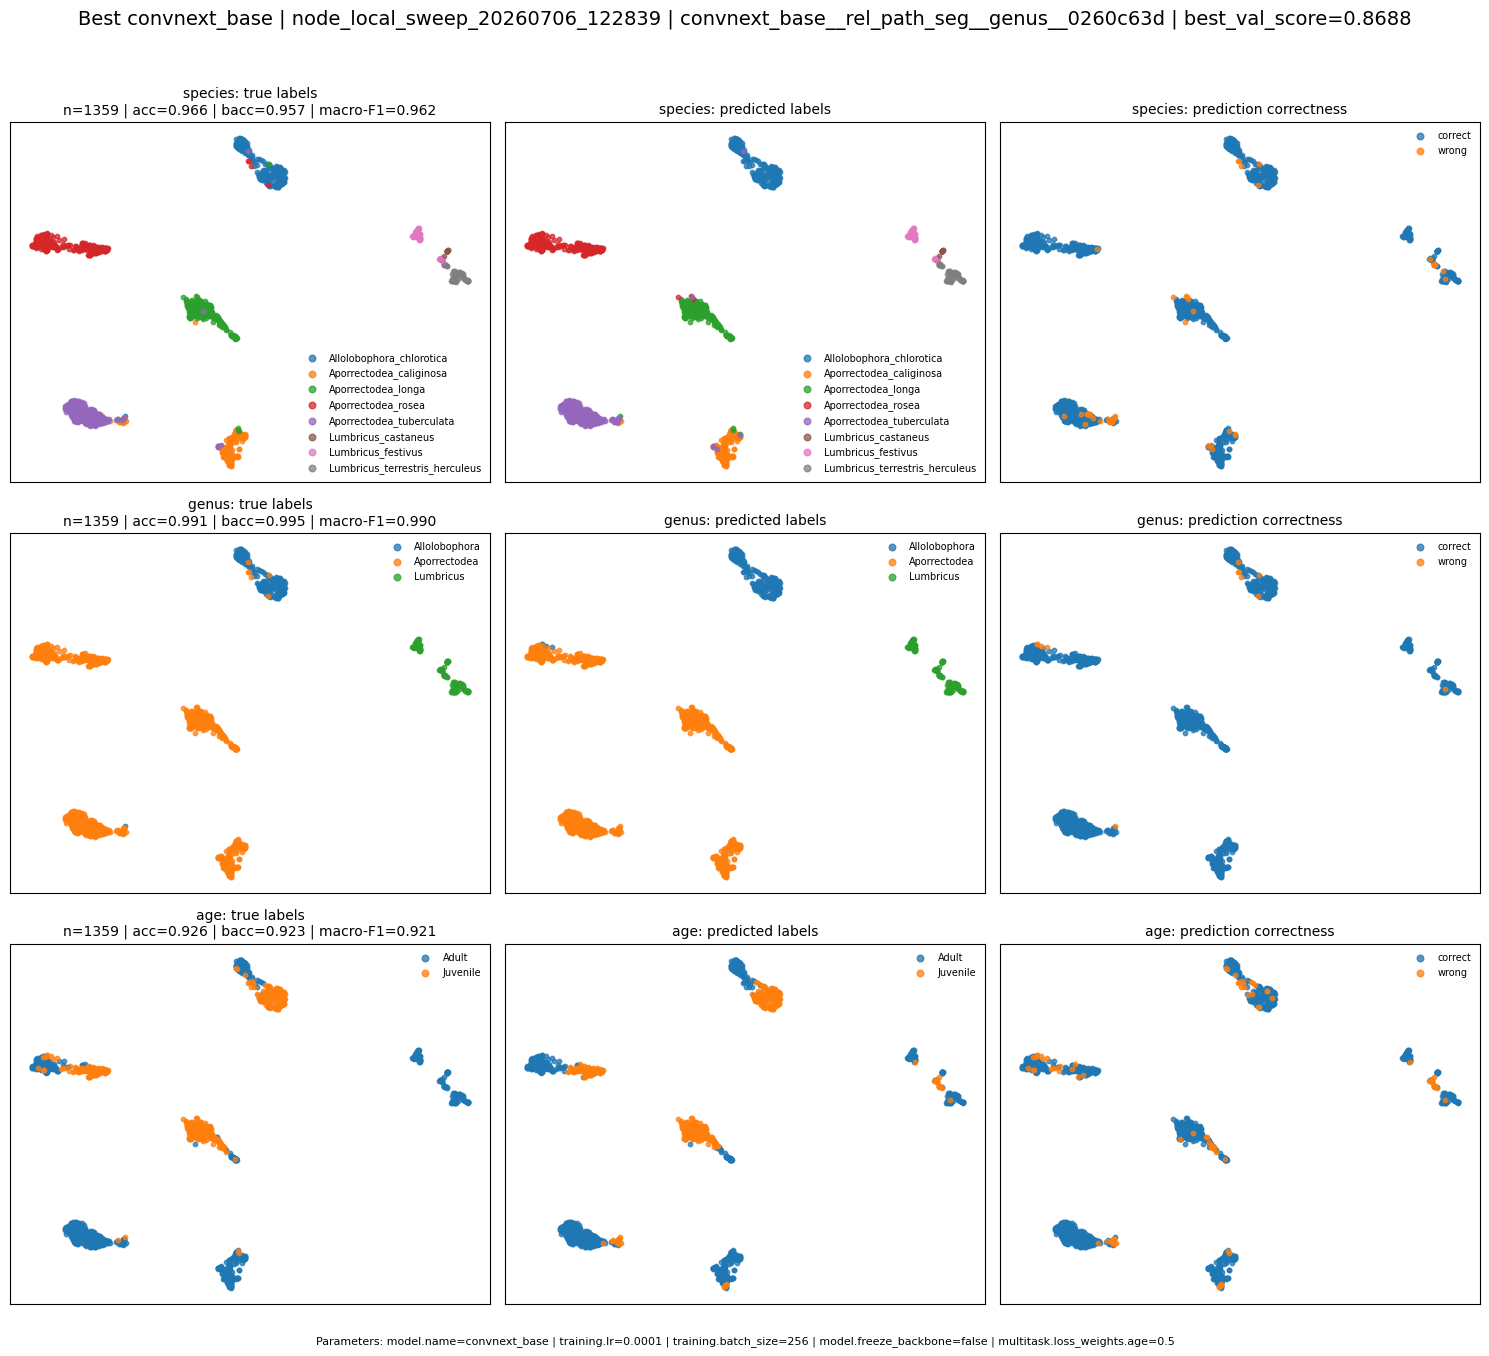

Best resnet18 | node_local_sweep_20260706_122839 | resnet18__rel_path_seg__genus__68d3b62a | best_val_score=0.8434
Model directory: /home/devd/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_179/resnet18__rel_path_seg__genus__68d3b62a
Parameters: model.name=resnet18 | training.lr=0.0003 | training.batch_size=256 | model.freeze_backbone=false | multitask.loss_weights.age=2.0

Strict species labels masked because of taxonomic uncertainty:
taxon_label
Aporrectodea_caliginosa_tuberculata    2115
Lumbricus_sp                            925
Name: count, dtype: int64
Initial dataset size: 6193
After removing invalid images, dataset size: 6191

Masking rare classes per task (min_individuals_per_class=3)

Classes retained for task 'genus' (genus):
genus
Aporrectodea     740
Lumbricus        189
Allolobophora    176
Name: barcode, dtype: int64

Classes retained for task 'species' (species_label):
species_label
Allolobophora_chlorotica          176
Aporrectodea_longa              

Extracting embeddings:   0%|          | 0/22 [00:00<?, ?it/s]

Extracted features: (1359, 512)


/home/devd/miniconda3/envs/wormspecies/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


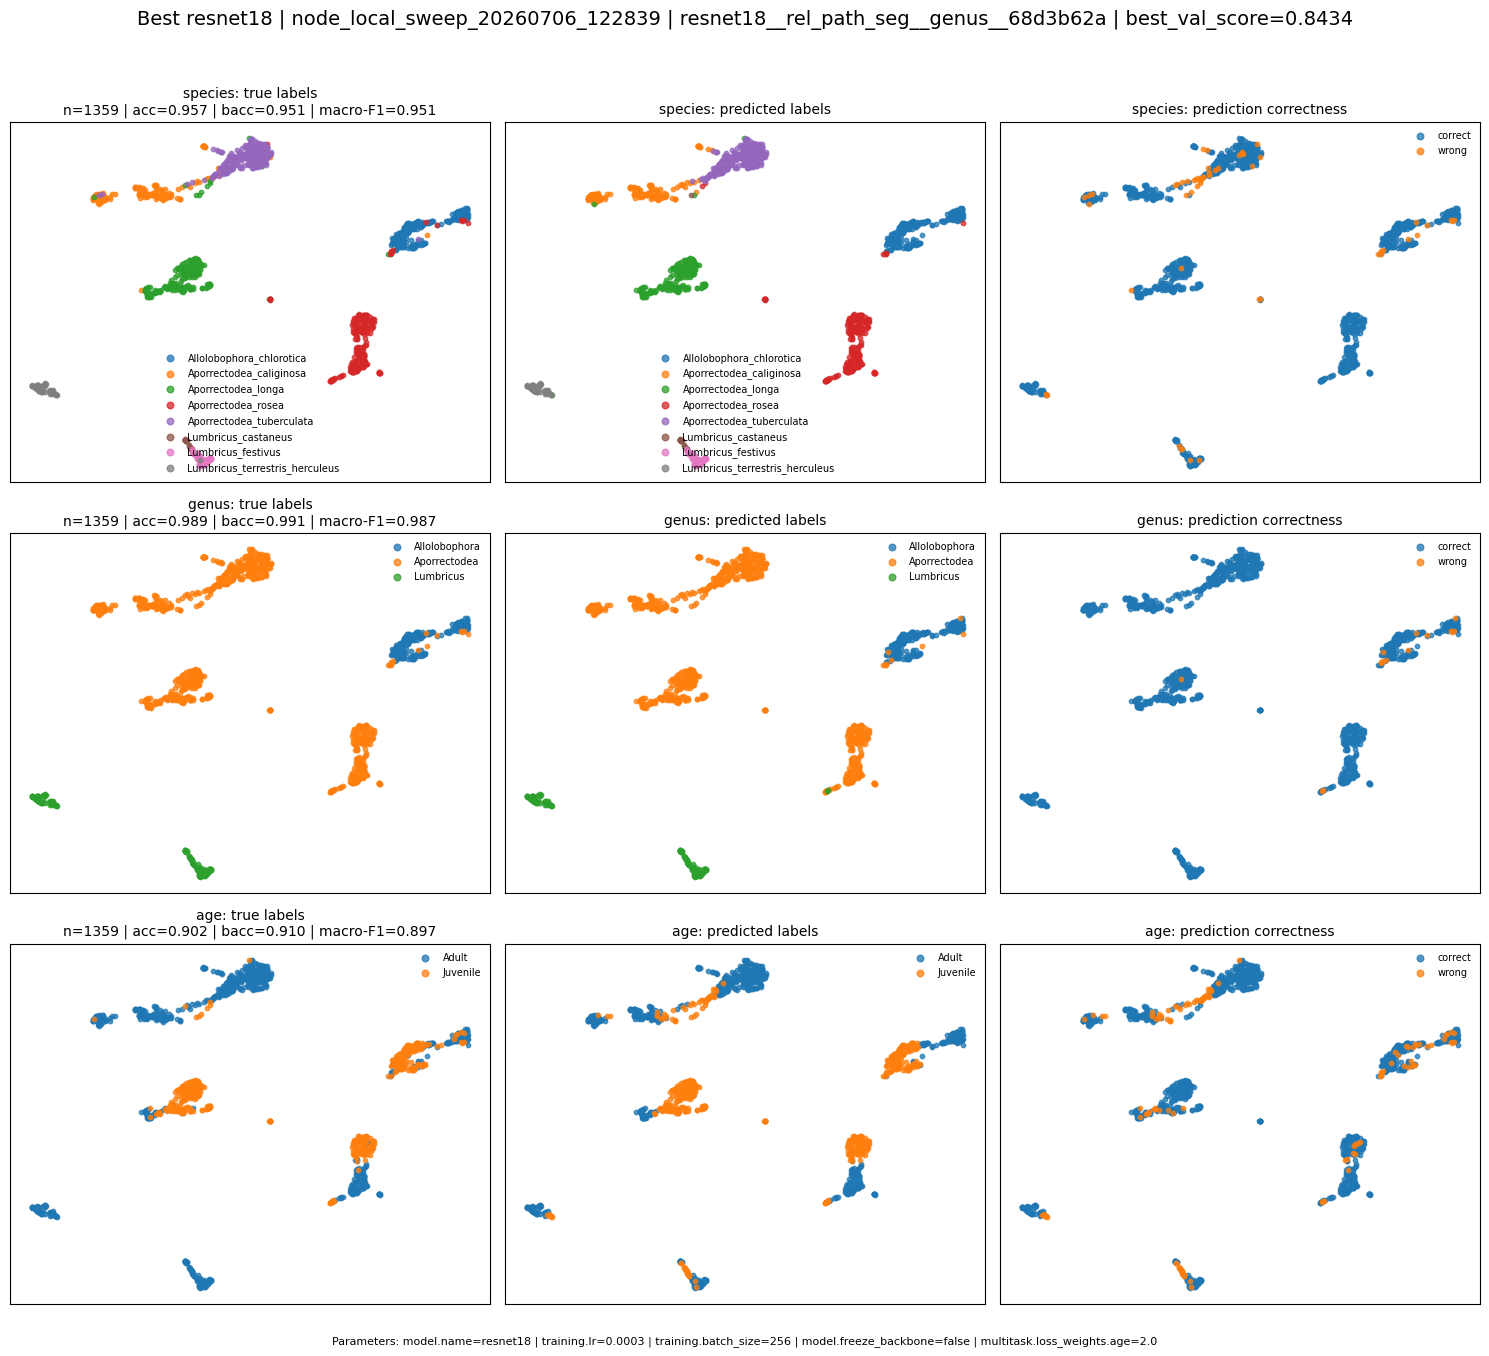

Best vit_b_16 | node_local_sweep_20260706_122839 | vit_b_16__rel_path_seg__genus__d413182b | best_val_score=0.8404
Model directory: /home/devd/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_146/vit_b_16__rel_path_seg__genus__d413182b
Parameters: model.name=vit_b_16 | training.lr=0.0001 | training.batch_size=256 | model.freeze_backbone=false | multitask.loss_weights.age=2.0

Strict species labels masked because of taxonomic uncertainty:
taxon_label
Aporrectodea_caliginosa_tuberculata    2115
Lumbricus_sp                            925
Name: count, dtype: int64
Initial dataset size: 6193
After removing invalid images, dataset size: 6191

Masking rare classes per task (min_individuals_per_class=3)

Classes retained for task 'genus' (genus):
genus
Aporrectodea     740
Lumbricus        189
Allolobophora    176
Name: barcode, dtype: int64

Classes retained for task 'species' (species_label):
species_label
Allolobophora_chlorotica          176
Aporrectodea_longa              

Extracting embeddings:   0%|          | 0/22 [00:00<?, ?it/s]

Extracted features: (1359, 768)


/home/devd/miniconda3/envs/wormspecies/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


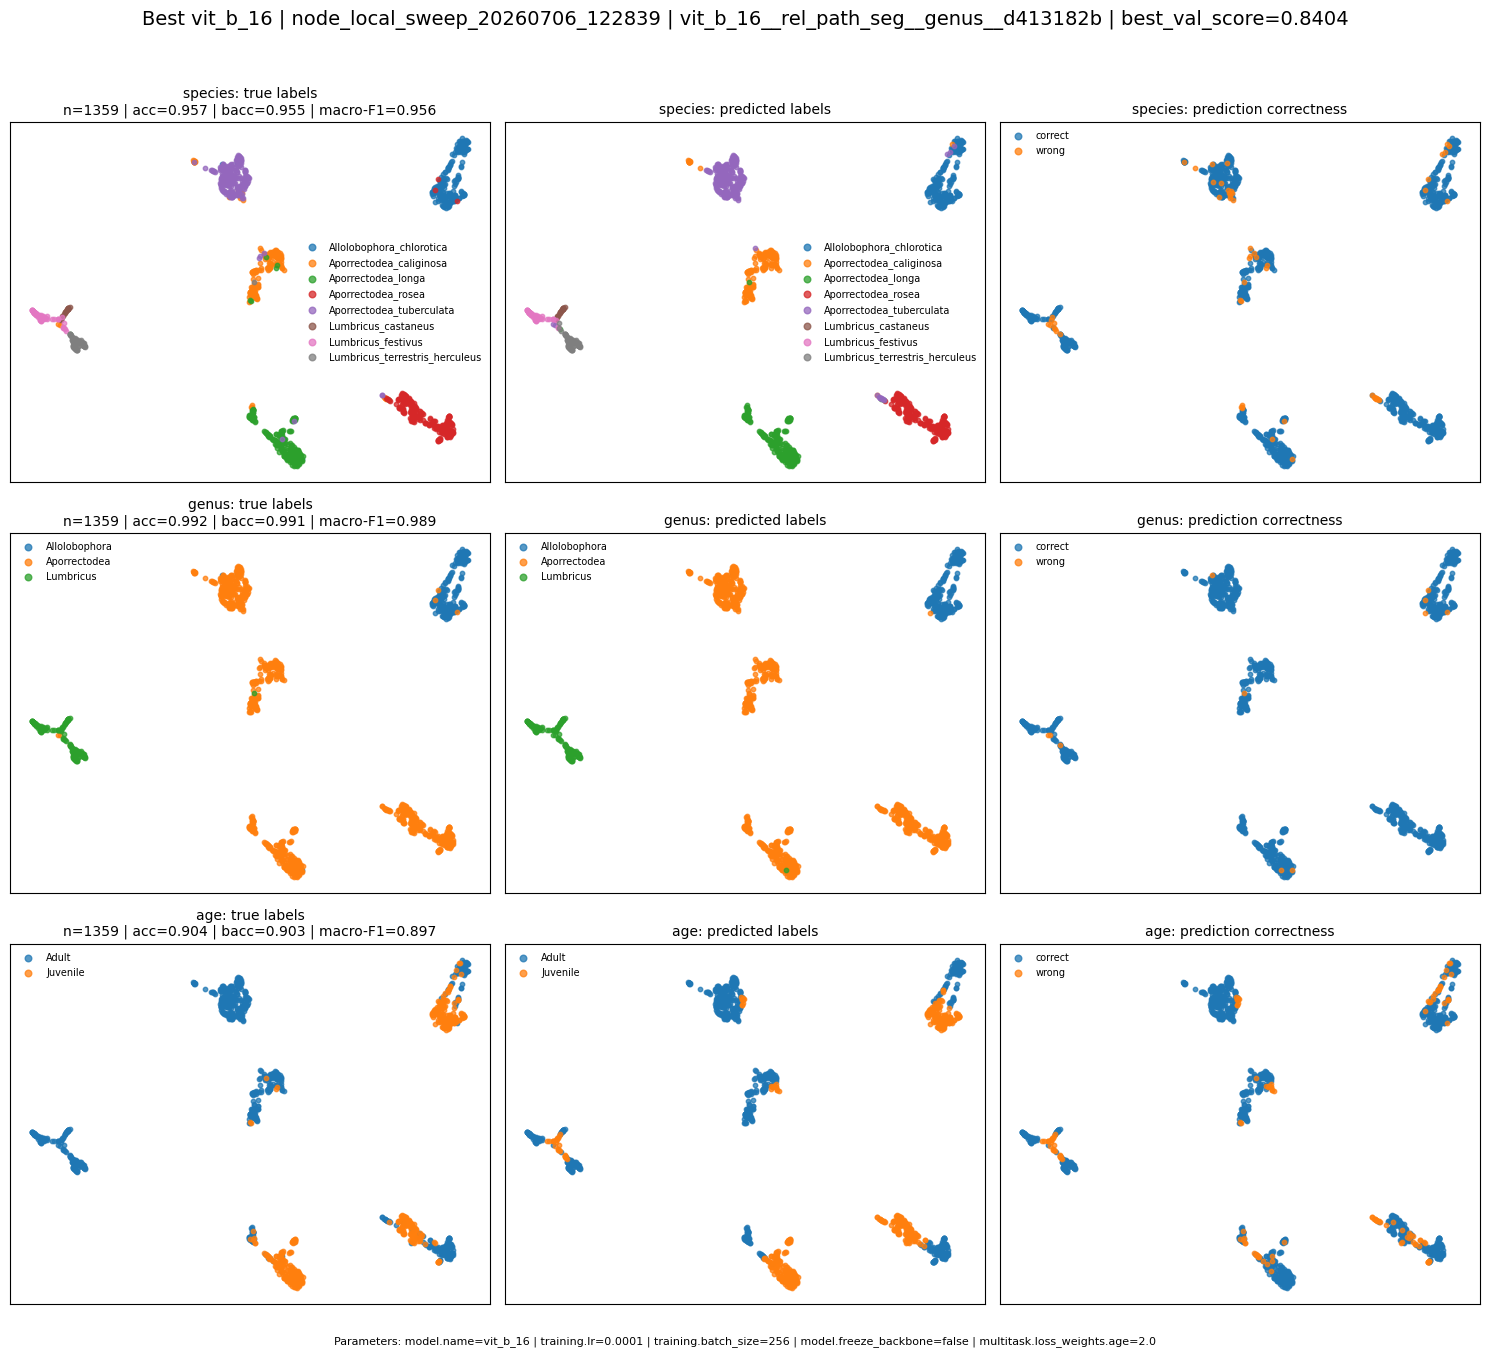

Best efficientnet_b1 | node_local_sweep_20260706_122839 | efficientnet_b1__rel_path_seg__genus__ba032066 | best_val_score=0.8283
Model directory: /home/devd/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_308/efficientnet_b1__rel_path_seg__genus__ba032066
Parameters: model.name=efficientnet_b1 | training.lr=0.0001 | training.batch_size=256 | model.freeze_backbone=false | multitask.loss_weights.age=2.0

Strict species labels masked because of taxonomic uncertainty:
taxon_label
Aporrectodea_caliginosa_tuberculata    2115
Lumbricus_sp                            925
Name: count, dtype: int64
Initial dataset size: 6193
After removing invalid images, dataset size: 6191

Masking rare classes per task (min_individuals_per_class=3)

Classes retained for task 'genus' (genus):
genus
Aporrectodea     740
Lumbricus        189
Allolobophora    176
Name: barcode, dtype: int64

Classes retained for task 'species' (species_label):
species_label
Allolobophora_chlorotica          176
Apor

Extracting embeddings:   0%|          | 0/22 [00:00<?, ?it/s]

Extracted features: (1359, 1280)


/home/devd/miniconda3/envs/wormspecies/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


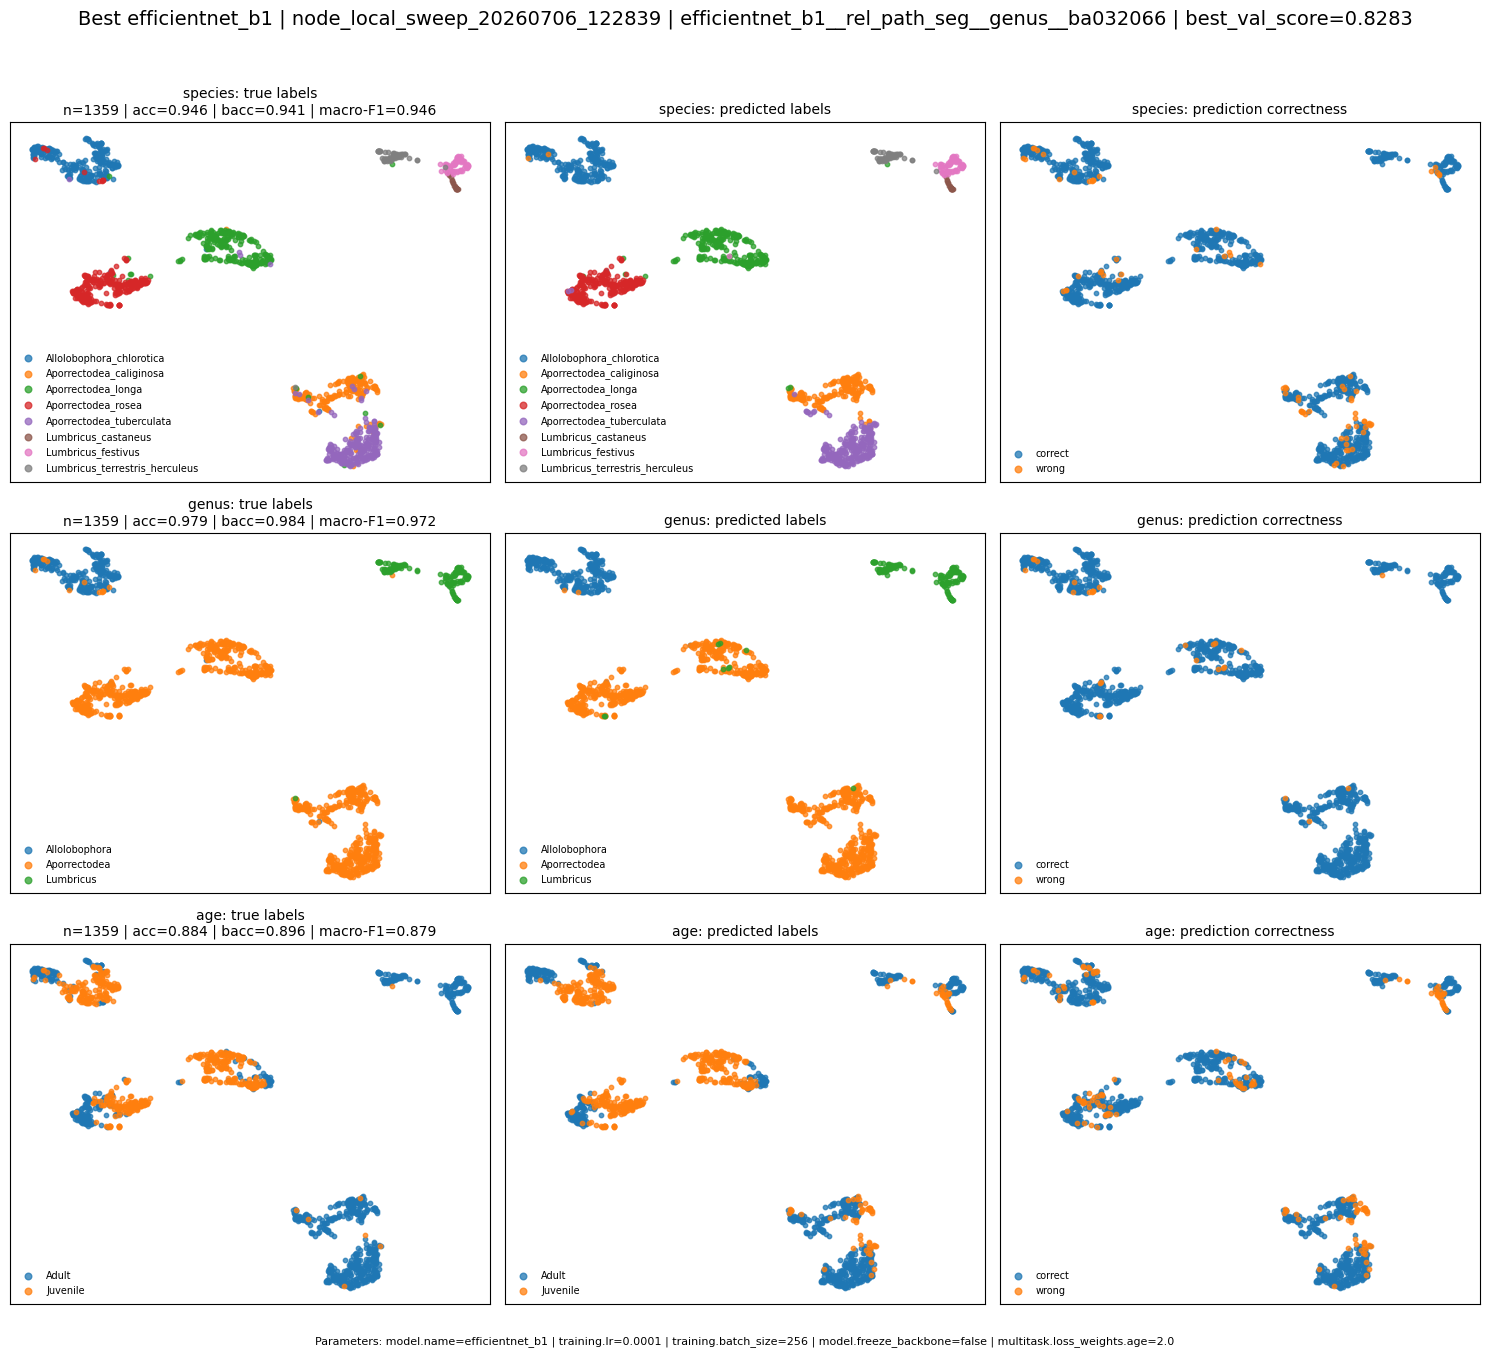

Best efficientnet_b0 | node_local_sweep_20260703_164317 | efficientnet_b0__rel_path_seg__genus__9a61bcaf | best_val_score=0.8224
Model directory: /home/devd/worm-species/outputs_slurm/node_local_sweep_20260703_164317/run_030/efficientnet_b0__rel_path_seg__genus__9a61bcaf
Parameters: model.name=efficientnet_b0 | training.lr=0.0001 | training.batch_size=256 | model.freeze_backbone=false | multitask.loss_weights.age=1.0

Strict species labels masked because of taxonomic uncertainty:
taxon_label
Aporrectodea_caliginosa_tuberculata    2115
Lumbricus_sp                            925
Name: count, dtype: int64
Initial dataset size: 6193
After removing invalid images, dataset size: 6191

Masking rare classes per task (min_individuals_per_class=3)

Classes retained for task 'genus' (genus):
genus
Aporrectodea     740
Lumbricus        189
Allolobophora    176
Name: barcode, dtype: int64

Classes retained for task 'species' (species_label):
species_label
Allolobophora_chlorotica          176
Apor

Extracting embeddings:   0%|          | 0/22 [00:00<?, ?it/s]

Extracted features: (1359, 1280)


/home/devd/miniconda3/envs/wormspecies/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


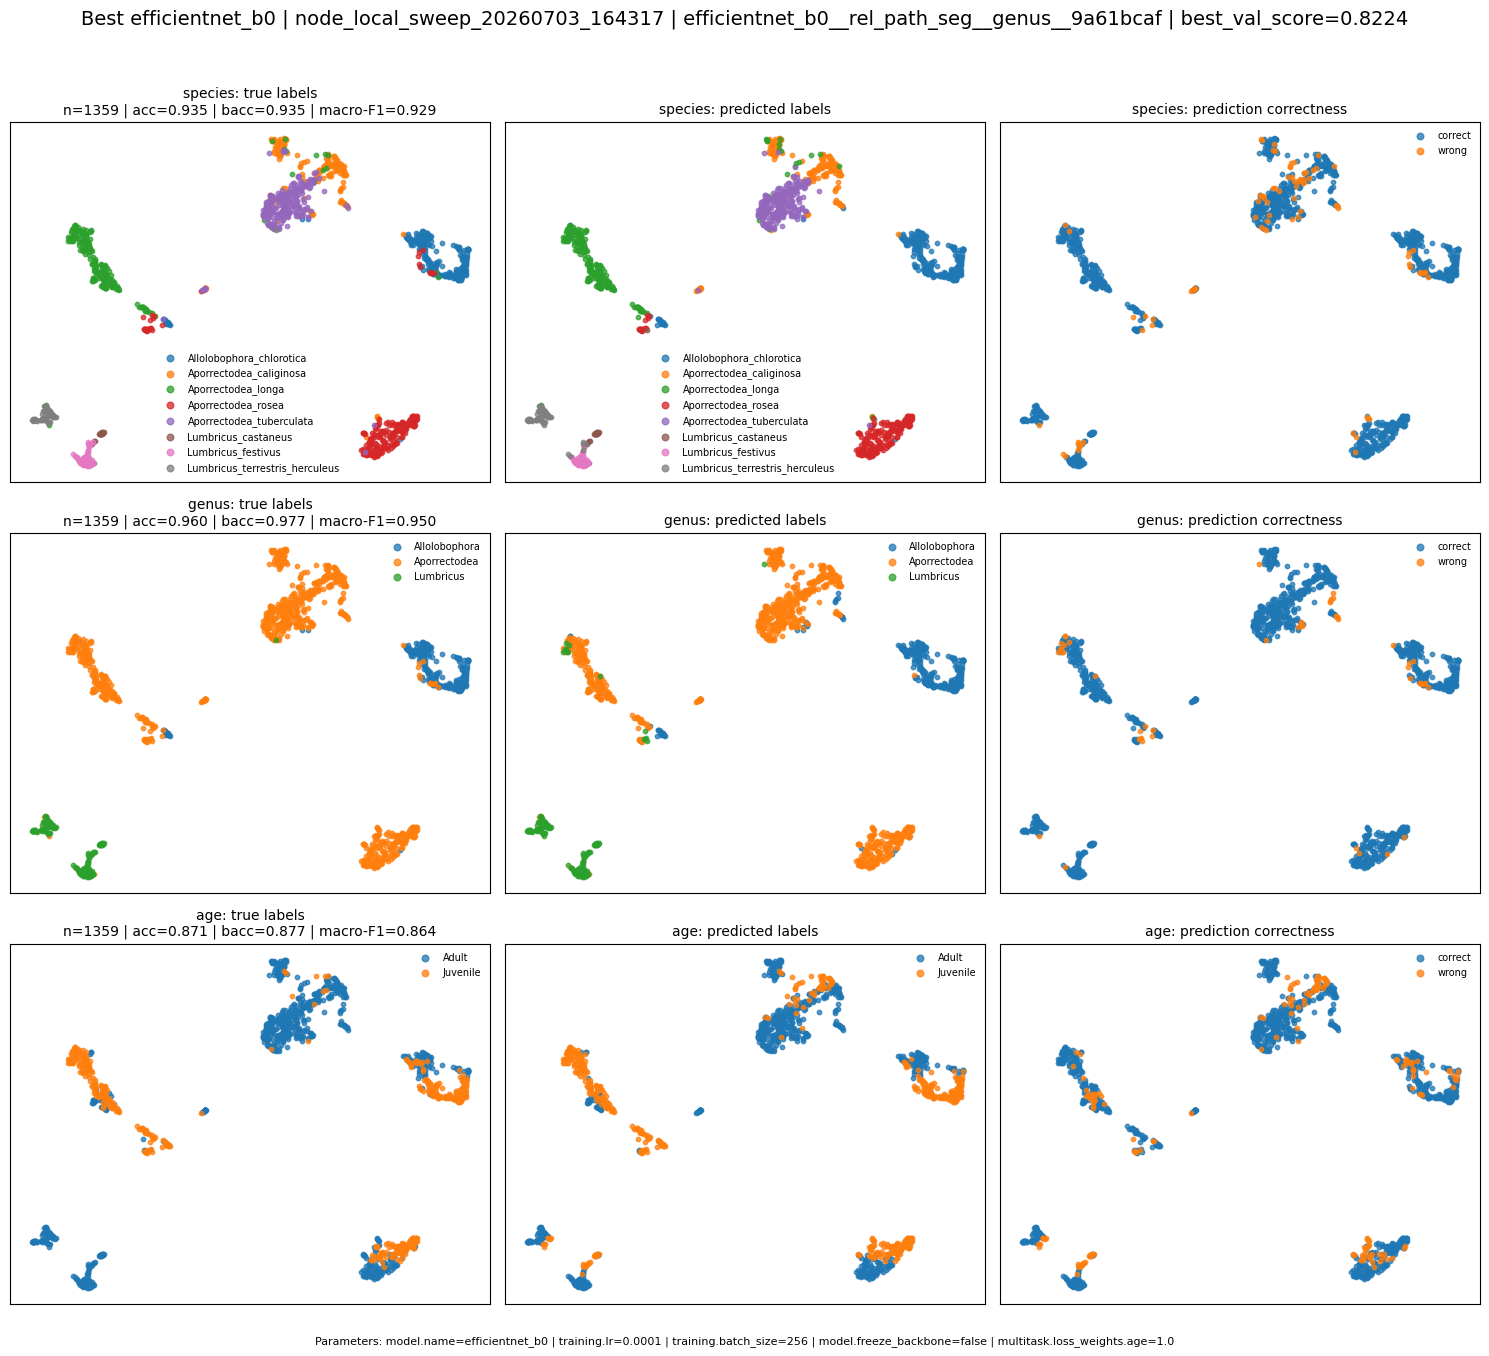

Best resnet50 | node_local_sweep_20260706_122839 | resnet50__rel_path_seg__genus__531efe2f | best_val_score=0.8179
Model directory: /home/devd/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_241/resnet50__rel_path_seg__genus__531efe2f
Parameters: model.name=resnet50 | training.lr=0.0003 | training.batch_size=256 | model.freeze_backbone=false | multitask.loss_weights.age=0.5

Strict species labels masked because of taxonomic uncertainty:
taxon_label
Aporrectodea_caliginosa_tuberculata    2115
Lumbricus_sp                            925
Name: count, dtype: int64
Initial dataset size: 6193
After removing invalid images, dataset size: 6191

Masking rare classes per task (min_individuals_per_class=3)

Classes retained for task 'genus' (genus):
genus
Aporrectodea     740
Lumbricus        189
Allolobophora    176
Name: barcode, dtype: int64

Classes retained for task 'species' (species_label):
species_label
Allolobophora_chlorotica          176
Aporrectodea_longa              

Extracting embeddings:   0%|          | 0/22 [00:00<?, ?it/s]

Extracted features: (1359, 2048)


/home/devd/miniconda3/envs/wormspecies/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


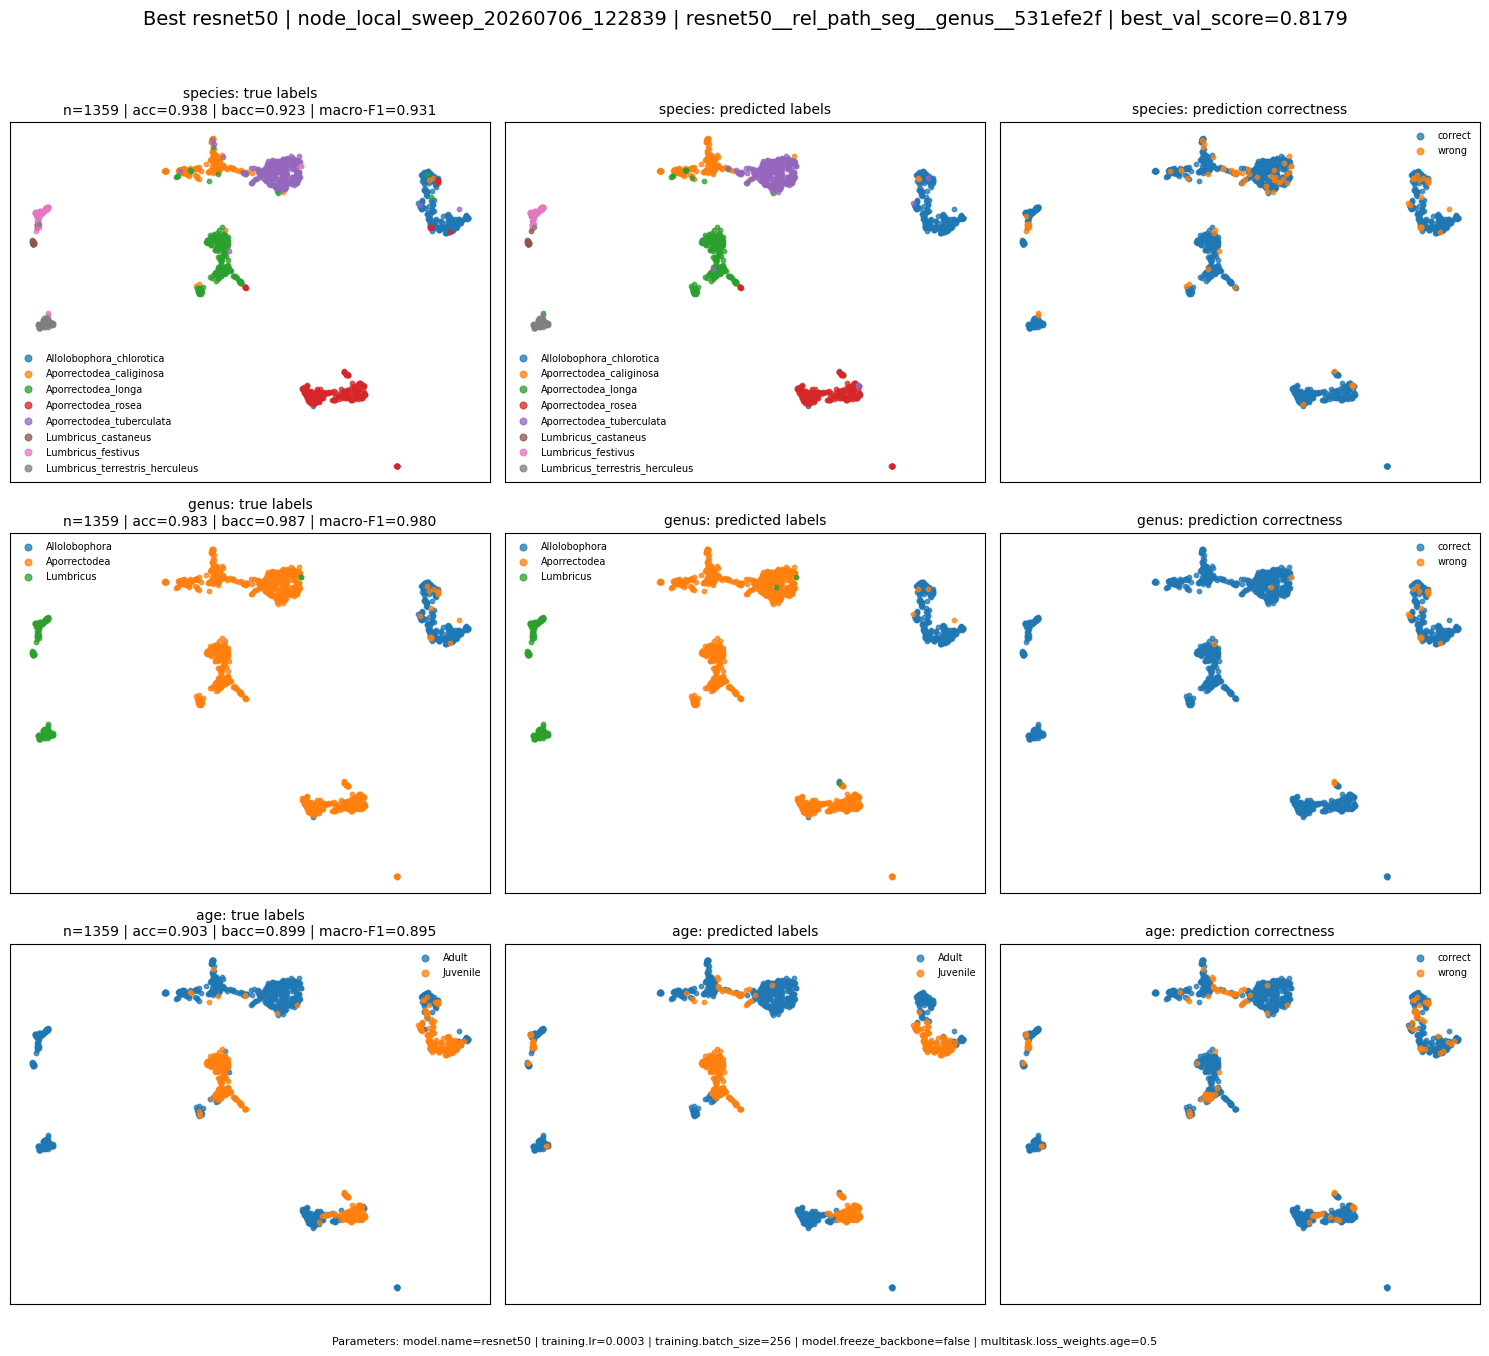


Saved outputs:
/home/devd/worm-species/outputs_slurm/combined_sweep_analysis/umap_top_model_families/convnext_base__convnext_base__rel_path_seg__genus__0260c63d/umap_metadata_with_predictions.csv
/home/devd/worm-species/outputs_slurm/combined_sweep_analysis/umap_top_model_families/convnext_base__convnext_base__rel_path_seg__genus__0260c63d/umap_embedding_2d.npy
/home/devd/worm-species/outputs_slurm/combined_sweep_analysis/umap_top_model_families/convnext_base__convnext_base__rel_path_seg__genus__0260c63d/umap_all_tasks_true_pred_correctness.png
/home/devd/worm-species/outputs_slurm/combined_sweep_analysis/umap_top_model_families/resnet18__resnet18__rel_path_seg__genus__68d3b62a/umap_metadata_with_predictions.csv
/home/devd/worm-species/outputs_slurm/combined_sweep_analysis/umap_top_model_families/resnet18__resnet18__rel_path_seg__genus__68d3b62a/umap_embedding_2d.npy
/home/devd/worm-species/outputs_slurm/combined_sweep_analysis/umap_top_model_families/resnet18__resnet18__rel_path_seg_

In [12]:
all_saved_paths = []
all_model_meta = []

for _, row in top_by_model.iterrows():
    model_type = str(row["model_type"])
    run_name = str(row["run_name"])
    model_dir = Path(row["artifact_dir"]).resolve()
    score = row[RANK_BY]

    override_text, override_path = read_run_overrides(row)
    parameter_summary = compact_overrides_text(override_text)

    run_label = (
        f"Best {model_type} | {row.get('sweep_id', '')} | "
        f"{run_name} | {RANK_BY}={score:.4f}"
    )

    run_out_dir = ANALYSIS_DIR / f"{safe_slug(model_type)}__{safe_slug(run_name)}"
    run_out_dir.mkdir(parents=True, exist_ok=True)

    print("=" * 120)
    print(run_label)
    print("Model directory:", model_dir)
    print(parameter_summary)

    (run_out_dir / "run_overrides.args").write_text(
        override_text if override_text else "run_overrides.args not found"
    )

    (run_out_dir / "run_summary.txt").write_text(
        "\n".join([
            run_label,
            f"Model type: {model_type}",
            f"Model directory: {model_dir}",
            f"Override file: {override_path if override_path is not None else 'not found'}",
            "",
            "Compact parameter summary:",
            parameter_summary,
            "",
            "Full run_overrides.args:",
            override_text if override_text else "not found",
        ])
    )

    bundle = load_model_bundle(model_dir)
    model = bundle["model"]
    cfg = bundle["cfg"]
    label_to_index_by_task = bundle["label_to_index_by_task"]
    index_to_label_by_task = bundle["index_to_label_by_task"]

    available_tasks = list(label_to_index_by_task.keys())

    eval_df, target_cols, root_dir, image_col, image_size, tasks = prepare_eval_dataframe(cfg, available_tasks)

    features, meta = extract_embeddings_and_predictions(
        model=model,
        df=eval_df,
        root_dir=root_dir,
        image_col=image_col,
        image_size=image_size,
        target_cols=target_cols,
        label_to_index_by_task=label_to_index_by_task,
        index_to_label_by_task=index_to_label_by_task,
        tasks=tasks,
    )

    print("Extracted features:", features.shape)

    embedding_2d = reduce_features_for_umap(features, random_state=RANDOM_STATE)

    meta["umap_1"] = embedding_2d[:, 0]
    meta["umap_2"] = embedding_2d[:, 1]
    meta["model_type"] = model_type
    meta["run_name"] = run_name
    meta["sweep_id"] = row.get("sweep_id", "")
    meta["rank_metric"] = RANK_BY
    meta["rank_score"] = score

    meta_path = run_out_dir / "umap_metadata_with_predictions.csv"
    meta.to_csv(meta_path, index=False)
    all_saved_paths.append(meta_path)

    embedding_path = run_out_dir / "umap_embedding_2d.npy"
    np.save(embedding_path, embedding_2d)
    all_saved_paths.append(embedding_path)

    plot_path = plot_umap_all_tasks(
        embedding_2d=embedding_2d,
        meta=meta,
        tasks=tasks,
        run_label=run_label,
        parameter_summary=parameter_summary,
        out_dir=run_out_dir,
    )
    all_saved_paths.append(plot_path)

    all_model_meta.append(meta)

combined_meta = pd.concat(all_model_meta, ignore_index=True)
combined_meta_path = ANALYSIS_DIR / "combined_umap_metadata_with_predictions.csv"
combined_meta.to_csv(combined_meta_path, index=False)
all_saved_paths.append(combined_meta_path)

print("\nSaved outputs:")
for p in all_saved_paths:
    print(p)


## 10. Optional: compare model families task-by-task

These figures place UMAP plots for each model family into one grid per task. Each model has its own UMAP coordinate system, so compare these panels qualitatively rather than as aligned coordinates.


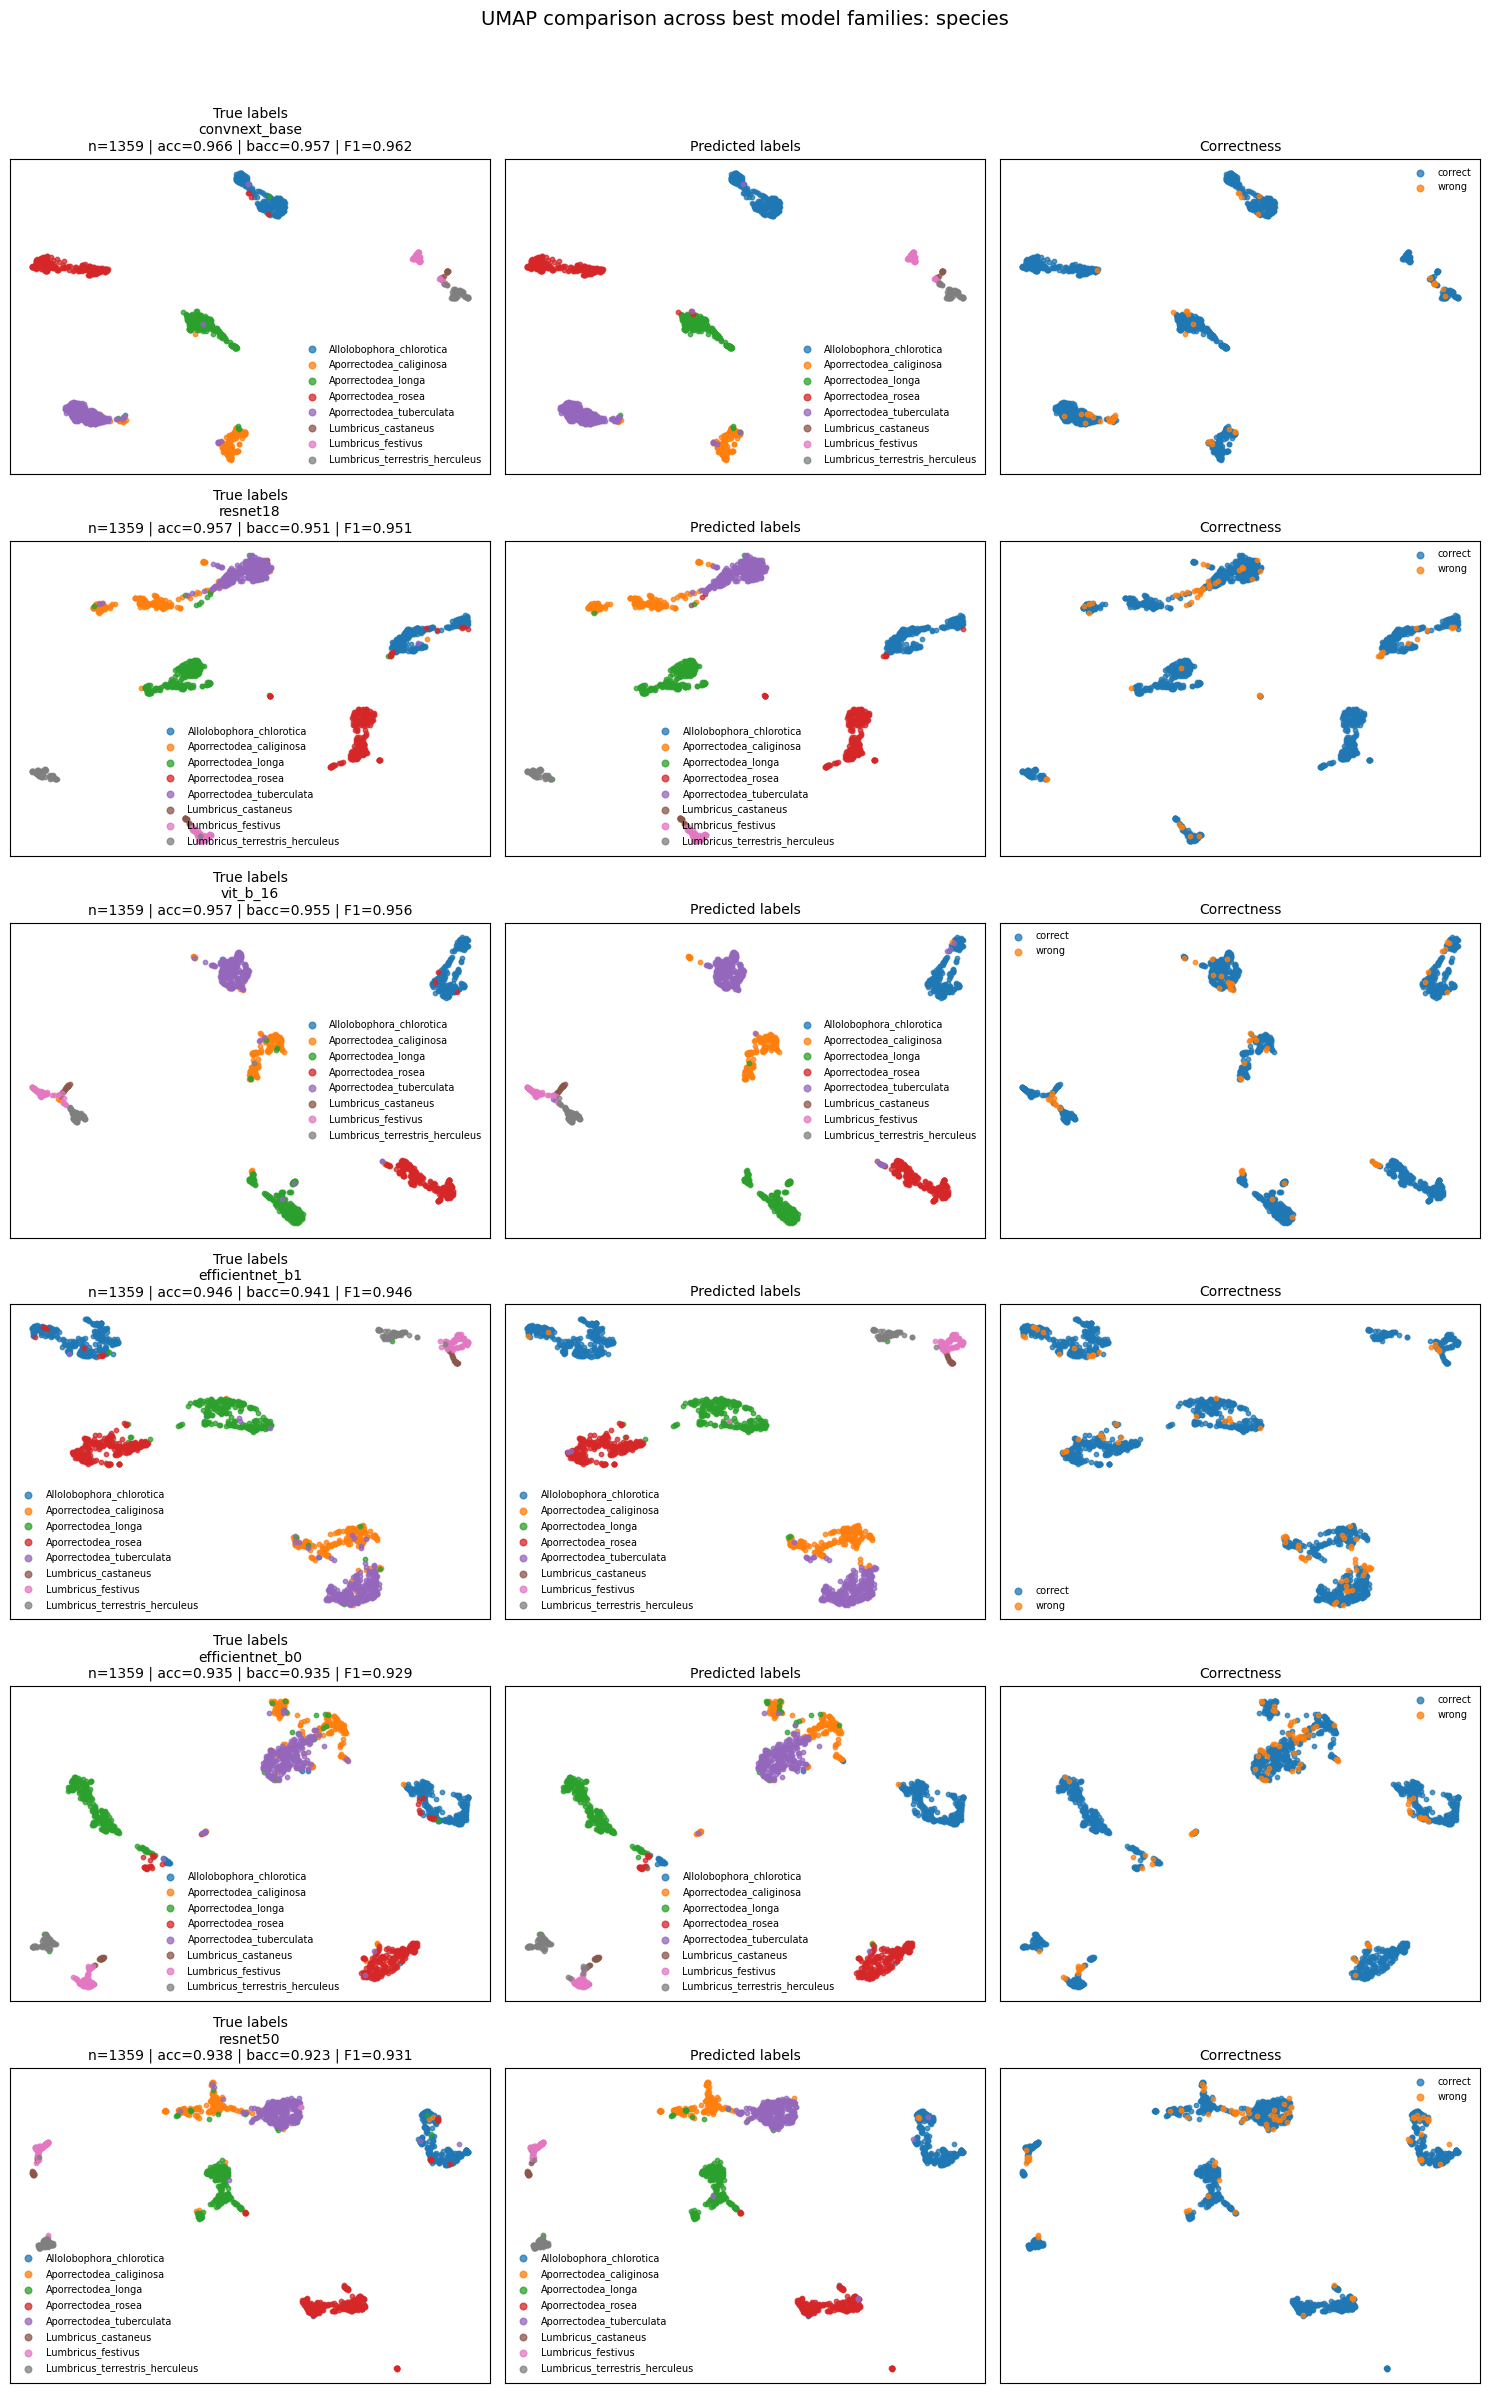

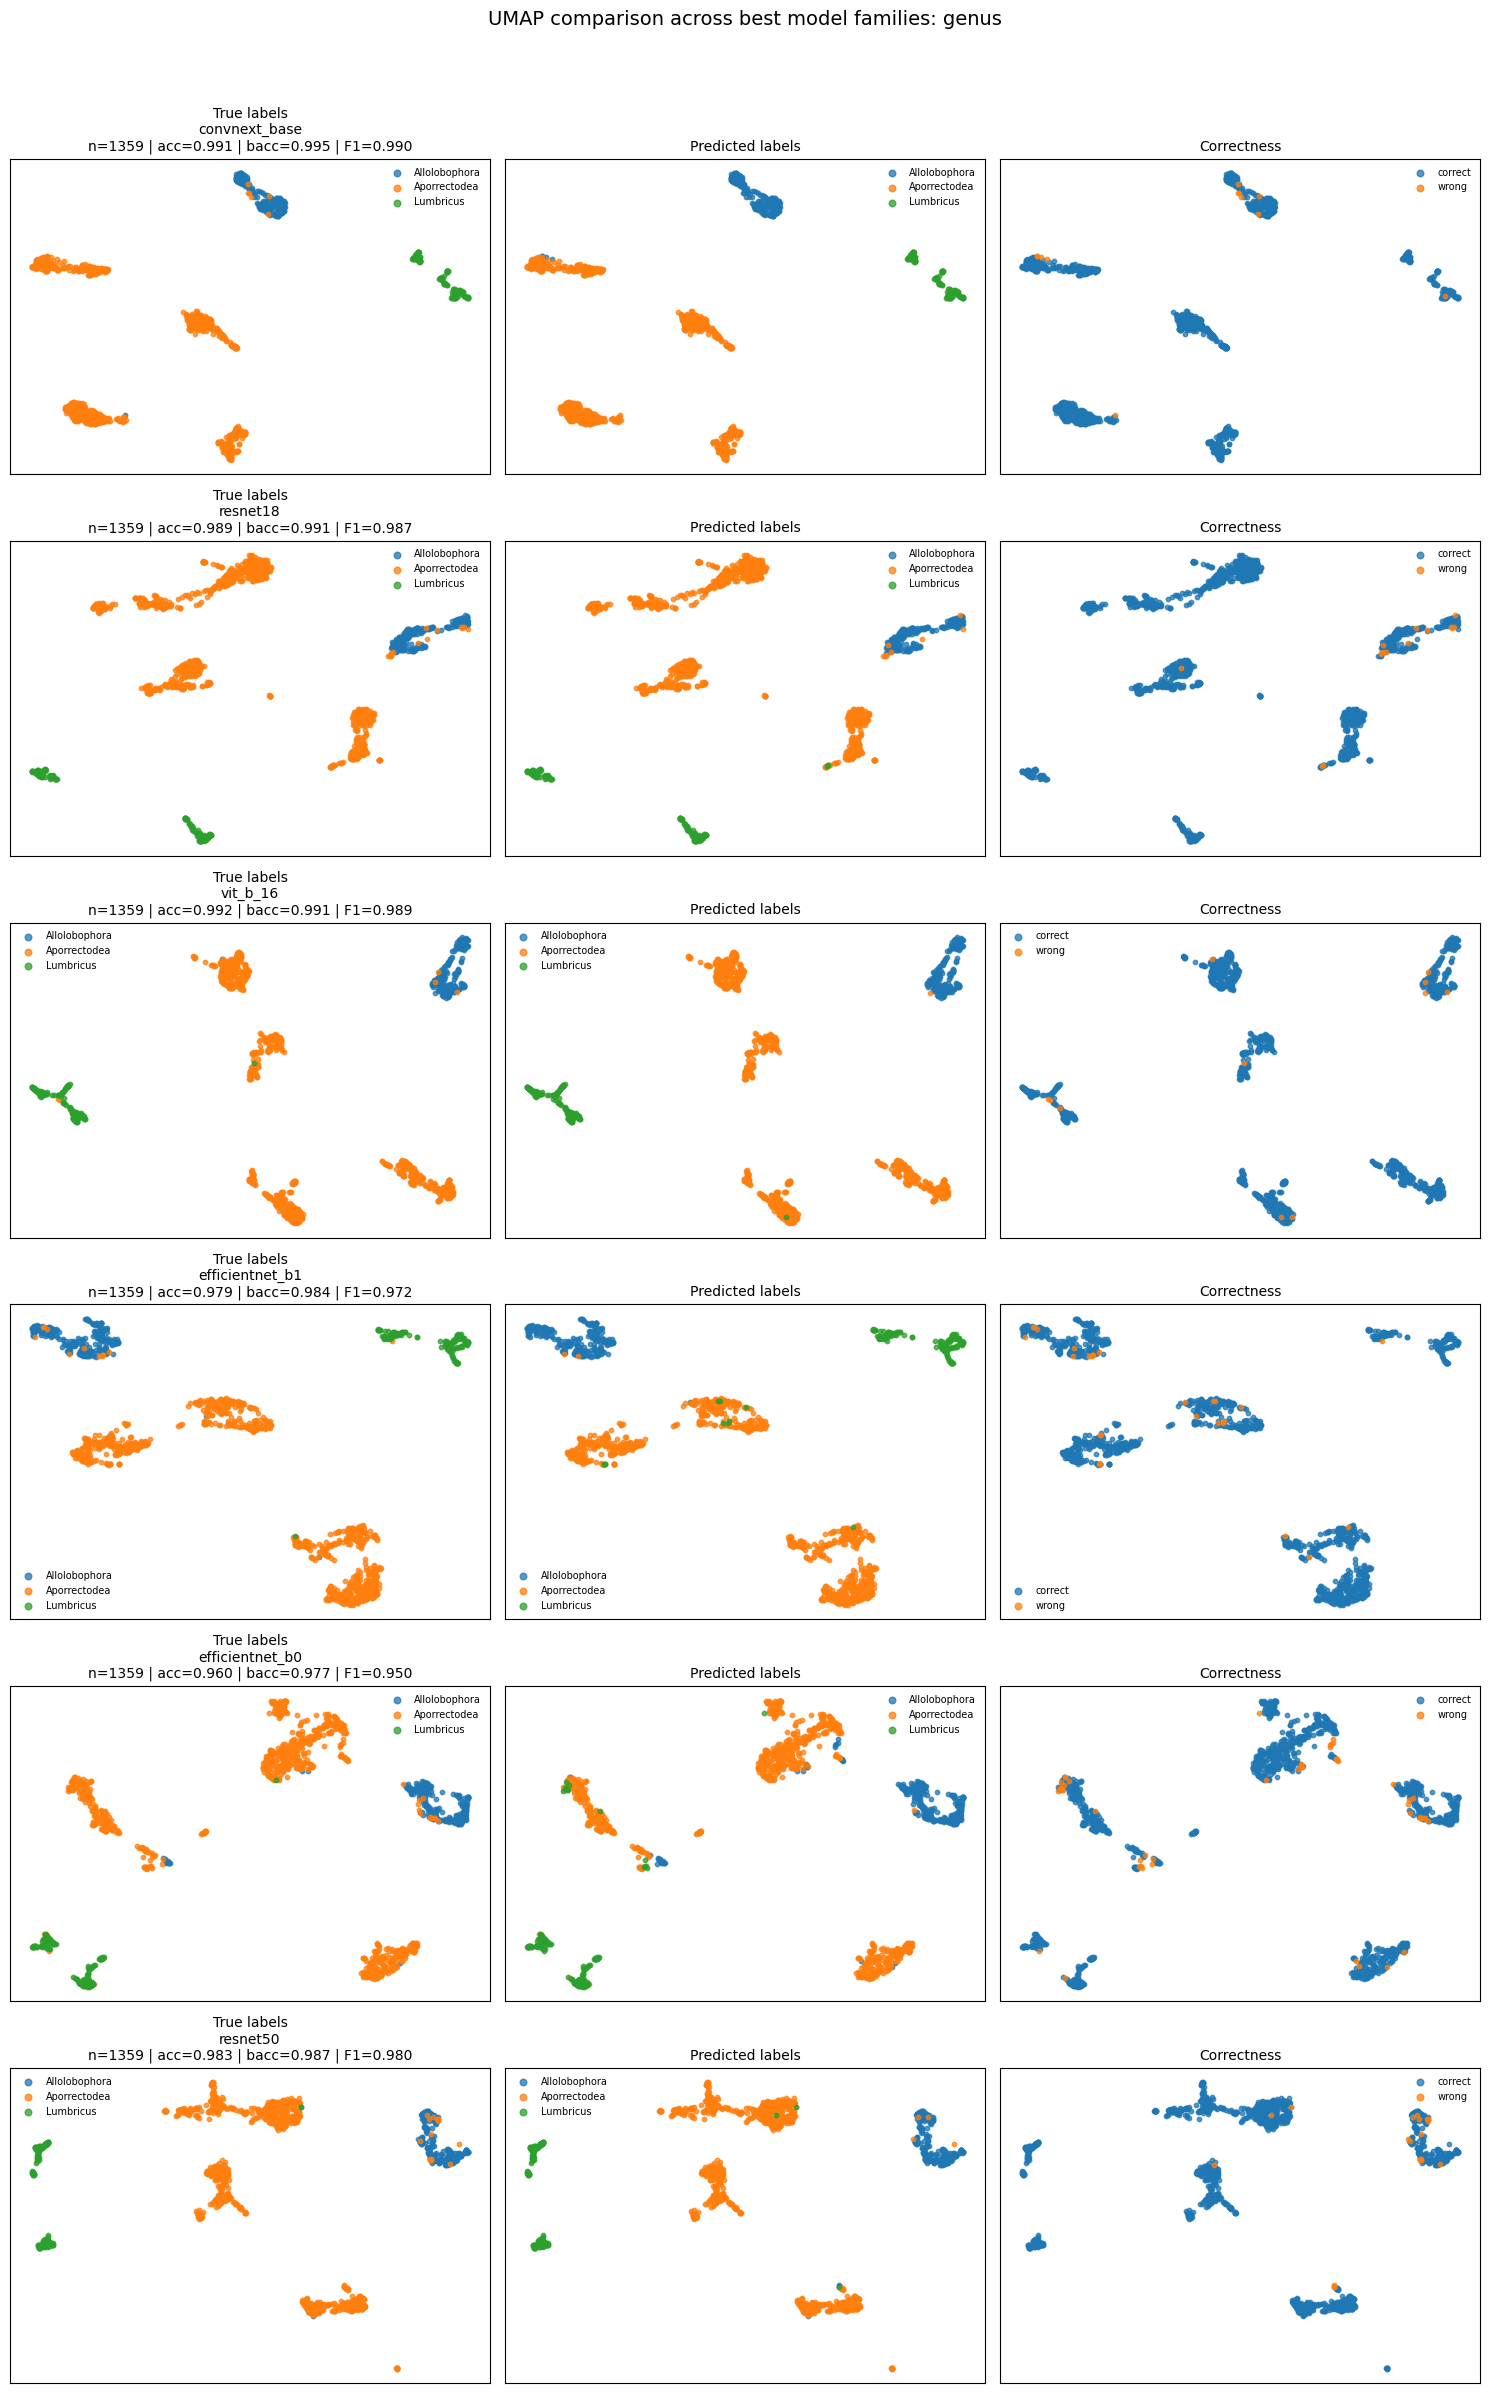

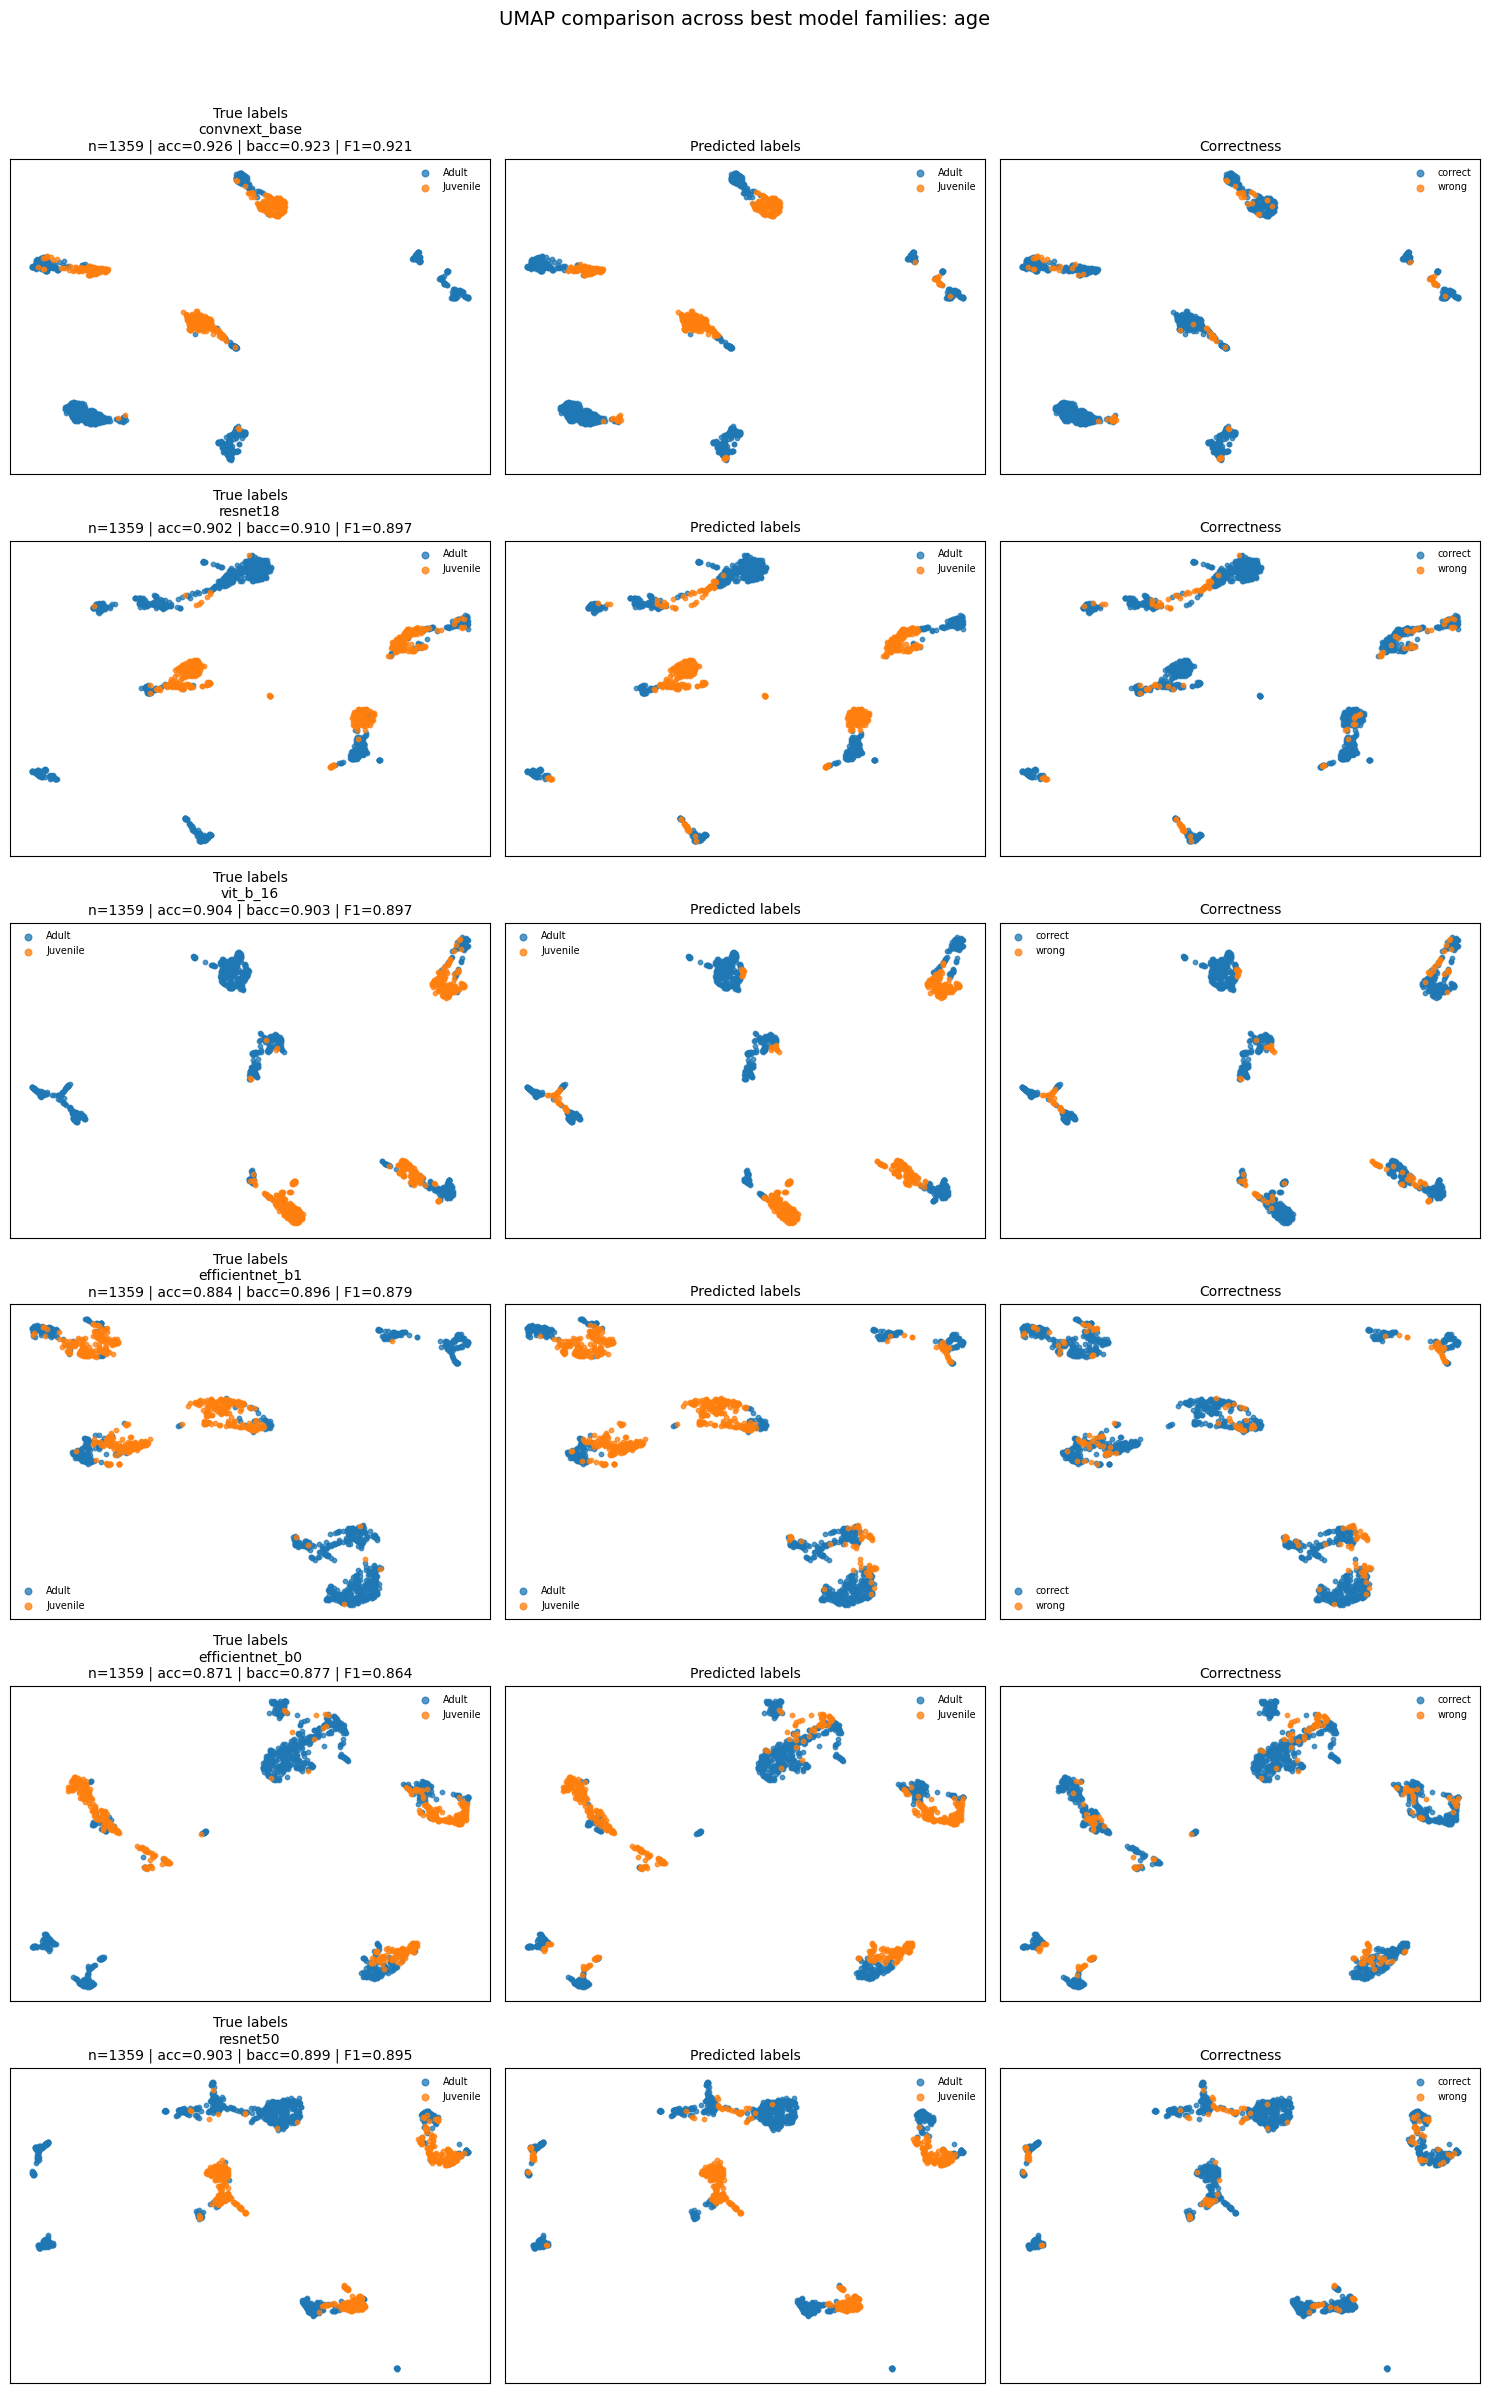

Saved comparison plots:
/home/devd/worm-species/outputs_slurm/combined_sweep_analysis/umap_top_model_families/umap_across_model_families_species.png
/home/devd/worm-species/outputs_slurm/combined_sweep_analysis/umap_top_model_families/umap_across_model_families_genus.png
/home/devd/worm-species/outputs_slurm/combined_sweep_analysis/umap_top_model_families/umap_across_model_families_age.png


In [13]:
comparison_paths = []

for task in TASKS_TO_PLOT:
    required_cols = {f"{task}_true", f"{task}_pred", f"{task}_correct"}
    if required_cols.issubset(set(combined_meta.columns)):
        path = plot_umap_task_grid_across_models(
            combined_meta=combined_meta,
            task=task,
            out_dir=ANALYSIS_DIR,
        )
        comparison_paths.append(path)

print("Saved comparison plots:")
for p in comparison_paths:
    print(p)


## 11. Notes for interpretation

UMAPs can reveal whether the learned embedding separates taxa or life stages, but they are sensitive to sampling, preprocessing, and UMAP parameters. Treat these plots as qualitative diagnostics.

Useful questions:

- Do species form coherent clusters in the embedding?
- Are misclassified images near class boundaries?
- Are genus clusters clearer than species clusters?
- Does age separate independently of species, or is age confounded with taxa?
- Do different model families show similar structure, or is one family relying on different visual cues?

For manuscript-quality claims, combine these visualisations with:

- held-out individual-level metrics;
- confusion matrices;
- per-class support counts;
- checks for acquisition/session/camera/folder confounding.
